In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import itertools

from scipy import stats as sps
from scipy.special import digamma, polygamma
from scipy import optimize

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform


In [4]:
def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    """Benjamini-Hochberg FDR for a 1D array."""
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranked = np.arange(1, n + 1)
    q = p[order] * n / ranked
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[order] = np.clip(q, 0, 1)
    return out


def inv_trigamma(y: float) -> float:
    """
    Invert trigamma(x) = y for y>0. Returns x>0.
    """
    if y <= 0:
        raise ValueError("y must be > 0 for inv_trigamma")

    f = lambda x: polygamma(1, x) - y

    low = 1e-8
    high = max(1.0 / y, 1e-6)

    while f(high) > 0 and high < 1e8:
        high *= 2.0

    root = optimize.brentq(f, low, high, maxiter=200, xtol=1e-12)
    return root


In [21]:
def eb_robust_outliers_for_sample(
    data: pd.DataFrame,
    sample_col: str,
    id_col: str = "transcript_id",
    tpm_cutoff: float = 0.1,
    min_prop: float = 0.05,
    target_tpm_keep: float = 0.1,
    pseudo: float = 1.0,
    robust_z_thresh: float = 4.0,
    pct_hi_thresh: float = 0.99,
    pct_lo_thresh: float = 0.01,
    q_thresh: float = 0.05,
    min_abs_diff_log2: float = 1.0,
) -> pd.DataFrame:
    """
    Leave-one-out, robust + EB single-sample isoform outlier detection.

    For a target sample:
      1) Filter isoforms:
         keep if:
           - target sample TPM >= target_tpm_keep
           OR
           - TPM >= tpm_cutoff in at least ceil(min_prop * n_samples) samples
      2) Transform Y = log2(TPM + pseudo)
      3) For each isoform, compute leave-one-out baseline from OTHER samples:
           - mean_others
           - median_others
           - MAD_others
           - percentile of target vs others
      4) Compute robust z-score:
           z_robust = (target - median_others) / (1.4826 * MAD_others)
      5) Compute EB-moderated residual score:
           residual = target - mean_others
           shrink variance of OTHER samples across isoforms
      6) Compute two-sided p-values, BH FDR
      7) Return metrics and boolean outlier flags

    Notes:
      - q-values here are useful for ranking, but still should be interpreted
        as an outlier screen rather than a perfect inferential model.
      - robust_z / percentile are often the most biologically interpretable columns.
    """
    assert id_col in data.columns, f"{id_col=} not found"
    assert sample_col in data.columns, f"{sample_col=} not found"

    sample_cols = [c for c in data.columns if c != id_col]
    n = len(sample_cols)
    if n < 4:
        raise ValueError("Need at least 4 samples total for leave-one-out analysis.")

    j = sample_cols.index(sample_col)

    # TPM matrix
    tpm = data[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=np.float64)
    ids = data[id_col].to_numpy()

    # Smarter filter:
    # keep if expressed in target sample OR expressed in enough cohort samples
    min_count = int(np.ceil(min_prop * n))
    keep = (tpm[:, j] >= target_tpm_keep) | ((tpm >= tpm_cutoff).sum(axis=1) >= min_count)

    if not np.any(keep):
        raise ValueError("No isoforms passed the expression filter; relax thresholds.")

    print(
        f"Keeping {keep.sum()} isoforms: "
        f"target TPM >= {target_tpm_keep} OR TPM >= {tpm_cutoff} in at least {min_count} samples."
    )

    tpm = tpm[keep, :]
    ids = ids[keep]

    # Log transform
    Y = np.log2(tpm + float(pseudo))
    m = Y.shape[0]

    # Split target vs others
    y_target = Y[:, j]
    Y_others = np.delete(Y, j, axis=1)  # shape (m, n-1)
    n_others = Y_others.shape[1]
    df_resid = n_others - 1

    if n_others < 3:
        raise ValueError("Need at least 3 background samples after leaving one out.")

    # Leave-one-out summary statistics
    mean_others = Y_others.mean(axis=1)
    median_others = np.median(Y_others, axis=1)
    mad_others = sps.median_abs_deviation(Y_others, axis=1, scale=1.0, nan_policy="omit")
    robust_scale = np.maximum(1e-6, 1.4826 * mad_others)

    diff_log2_mean = y_target - mean_others
    diff_log2_median = y_target - median_others

    # Robust z-score vs others
    z_robust = diff_log2_median / robust_scale

    # Percentiles: fraction of others <= target
    pct = np.mean(Y_others <= y_target[:, None], axis=1)

    # Direction
    direction = np.where(diff_log2_median >= 0, "higher_in_sample", "lower_in_sample")

    # EB variance on OTHER samples only
    R_other = Y_others - mean_others[:, None]
    s2 = np.sum(R_other**2, axis=1) / df_resid

    # limma-style shrinkage on log variances
    a = df_resid / 2.0
    log_s2 = np.log(s2 + 1e-300)
    mean_log_s2 = log_s2.mean()
    var_log_s2 = log_s2.var(ddof=1)

    s02 = np.exp(mean_log_s2 - (digamma(a) - np.log(a)))

    target_var = var_log_s2 - polygamma(1, a)
    if target_var <= 1e-12:
        df0 = np.inf
    else:
        a0 = inv_trigamma(target_var)
        df0 = 2.0 * a0

    if np.isfinite(df0):
        s2_post = (df0 * s02 + df_resid * s2) / (df0 + df_resid)
        df_post = df0 + df_resid
    else:
        s2_post = np.full_like(s2, s02)
        df_post = np.inf

    # EB moderated residual for target sample vs leave-one-out mean
    # predictive-ish SE: sqrt(s2_post * (1 + 1/n_others))
    se_target = np.sqrt(s2_post * (1.0 + 1.0 / n_others))
    t_mod = diff_log2_mean / np.maximum(se_target, 1e-12)

    # Raw p-values
    if np.isfinite(df_post):
        p_raw = 2.0 * sps.t.sf(np.abs(t_mod), df=df_post)
    else:
        p_raw = 2.0 * sps.norm.sf(np.abs(t_mod))

    # Heavy-tail correction
    kurt_excess = sps.kurtosis(t_mod, fisher=True, bias=False, nan_policy="omit")
    if np.isfinite(df_post) and np.isfinite(kurt_excess) and kurt_excess > 0:
        nu_hat = 4.0 + 6.0 / kurt_excess
        df_eff = min(df_post, nu_hat)
    else:
        df_eff = df_post

    if np.isfinite(df_eff):
        p_ttail = 2.0 * sps.t.sf(np.abs(t_mod), df=df_eff)
    else:
        p_ttail = 2.0 * sps.norm.sf(np.abs(t_mod))

    q_raw = bh_fdr(p_raw)
    q_ttail = bh_fdr(p_ttail)

    # Back to TPM for interpretability
    tpm_target = tpm[:, j]
    tpm_others = np.delete(tpm, j, axis=1)
    mean_tpm_others = tpm_others.mean(axis=1)
    median_tpm_others = np.median(tpm_others, axis=1)

    # Boolean calls
    robust_high_flag = (z_robust >= robust_z_thresh) | (pct >= pct_hi_thresh)
    robust_low_flag  = (z_robust <= -robust_z_thresh) | (pct <= pct_lo_thresh)

    eb_flag = (q_raw <= q_thresh) & (np.abs(diff_log2_median) >= min_abs_diff_log2)

    final_high_flag = robust_high_flag & eb_flag & (diff_log2_median > 0)
    final_low_flag  = robust_low_flag & eb_flag & (diff_log2_median < 0)
    final_any_flag  = final_high_flag | final_low_flag

    out = pd.DataFrame({
        "transcript_id": ids,
        "sample": sample_col,

        "TPM_sample": tpm_target,
        "mean_TPM_others": mean_tpm_others,
        "median_TPM_others": median_tpm_others,

        "log2TPM_sample": y_target,
        "mean_log2TPM_others": mean_others,
        "median_log2TPM_others": median_others,

        "diff_log2_mean": diff_log2_mean,
        "diff_log2_median": diff_log2_median,

        "mad_others": mad_others,
        "robust_scale": robust_scale,
        "z_robust": z_robust,
        "percentile_vs_others": pct,

        "t_mod": t_mod,
        "p_raw_dfpost": p_raw,
        "q_raw_dfpost": q_raw,
        "p_ttail": p_ttail,
        "q_ttail": q_ttail,
        "df_post": df_post if np.isfinite(df_post) else np.inf,
        "s2_post": s2_post,

        "direction": direction,
        "robust_high_flag": robust_high_flag,
        "robust_low_flag": robust_low_flag,
        "eb_flag": eb_flag,
        "final_high_flag": final_high_flag,
        "final_low_flag": final_low_flag,
        "final_any_flag": final_any_flag,
    })

    out = out.sort_values(
        ["final_any_flag", "q_ttail", "p_ttail", "z_robust"],
        ascending=[False, True, True, False]
    ).reset_index(drop=True)

    return out

In [45]:
def eb_robust_outliers_for_two_samples(
    data: pd.DataFrame,
    sample_cols_target: list,
    id_col: str = "transcript_id",
    tpm_cutoff: float = 0.1,
    min_prop: float = 0.05,
    target_tpm_keep: float = 0.1,
    pseudo: float = 1.0,
    robust_z_thresh: float = 4.0,
    pct_hi_thresh: float = 0.99,
    pct_lo_thresh: float = 0.01,
    q_thresh: float = 0.05,
    min_abs_diff_log2: float = 1.0,
    use_q: str = "raw",   # "raw" or "ttail"
) -> pd.DataFrame:
    """
    Two-sample vs rest robust + EB isoform outlier detection.

    Parameters
    ----------
    data : pd.DataFrame
        TPM matrix with transcript_id column and sample columns.
    sample_cols_target : list
        Exactly two target sample columns.
    id_col : str
        Transcript ID column.
    use_q : str
        "raw" uses q_raw_dfpost, "ttail" uses q_ttail for eb_flag.

    Returns
    -------
    pd.DataFrame
        Outlier summary per transcript for the two target samples together.
    """
    assert id_col in data.columns, f"{id_col=} not found"
    if len(sample_cols_target) != 2:
        raise ValueError("sample_cols_target must contain exactly 2 sample names")

    sample_cols = [c for c in data.columns if c != id_col]

    for s in sample_cols_target:
        if s not in sample_cols:
            raise ValueError(f"Target sample {s!r} not found in data columns")

    n = len(sample_cols)
    if n < 6:
        raise ValueError("Need at least 6 total samples for stable 2-vs-rest analysis")

    j_idx = [sample_cols.index(s) for s in sample_cols_target]
    other_idx = [i for i in range(n) if i not in j_idx]

    # TPM matrix
    tpm = data[sample_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=np.float64)
    ids = data[id_col].to_numpy()

    # Keep if either target sample expresses it OR enough cohort samples express it
    min_count = int(np.ceil(min_prop * n))
    keep = (
        (tpm[:, j_idx[0]] >= target_tpm_keep) |
        (tpm[:, j_idx[1]] >= target_tpm_keep) |
        ((tpm >= tpm_cutoff).sum(axis=1) >= min_count)
    )

    if not np.any(keep):
        raise ValueError("No isoforms passed the expression filter; relax thresholds.")

    print(
        f"Keeping {keep.sum()} isoforms: "
        f"target TPM >= {target_tpm_keep} in either target OR "
        f"TPM >= {tpm_cutoff} in at least {min_count} samples."
    )

    tpm = tpm[keep, :]
    ids = ids[keep]

    # Log transform
    Y = np.log2(tpm + float(pseudo))

    # Split targets vs others
    Y_target = Y[:, j_idx]          # shape (m, 2)
    Y_others = Y[:, other_idx]      # shape (m, n_other)
    n_other = Y_others.shape[1]

    if n_other < 4:
        raise ValueError("Need at least 4 non-target samples")

    # Leave-two-out baseline from others
    mean_others = Y_others.mean(axis=1)
    median_others = np.median(Y_others, axis=1)
    mad_others = sps.median_abs_deviation(Y_others, axis=1, scale=1.0, nan_policy="omit")
    robust_scale = np.maximum(1e-6, 1.4826 * mad_others)

    # Per-target robust metrics
    y1 = Y_target[:, 0]
    y2 = Y_target[:, 1]

    diff1_log2_median = y1 - median_others
    diff2_log2_median = y2 - median_others

    z1 = diff1_log2_median / robust_scale
    z2 = diff2_log2_median / robust_scale

    pct1 = np.mean(Y_others <= y1[:, None], axis=1)
    pct2 = np.mean(Y_others <= y2[:, None], axis=1)

    # Mean of targets vs others
    y_target_mean = Y_target.mean(axis=1)
    diff_log2_mean = y_target_mean - mean_others
    diff_log2_median = y_target_mean - median_others

    direction = np.where(diff_log2_median >= 0, "higher_in_target_pair", "lower_in_target_pair")

    # TPM summaries
    tpm1 = tpm[:, j_idx[0]]
    tpm2 = tpm[:, j_idx[1]]
    mean_tpm_target = (tpm1 + tpm2) / 2.0

    tpm_others = tpm[:, other_idx]
    mean_tpm_others = tpm_others.mean(axis=1)
    median_tpm_others = np.median(tpm_others, axis=1)

    # EB variance on others only
    R_other = Y_others - mean_others[:, None]
    df_resid = n_other - 1
    s2 = np.sum(R_other**2, axis=1) / df_resid

    a = df_resid / 2.0
    log_s2 = np.log(s2 + 1e-300)
    mean_log_s2 = log_s2.mean()
    var_log_s2 = log_s2.var(ddof=1)

    s02 = np.exp(mean_log_s2 - (digamma(a) - np.log(a)))

    target_var = var_log_s2 - polygamma(1, a)
    if target_var <= 1e-12:
        df0 = np.inf
    else:
        a0 = inv_trigamma(target_var)
        df0 = 2.0 * a0

    if np.isfinite(df0):
        s2_post = (df0 * s02 + df_resid * s2) / (df0 + df_resid)
        df_post = df0 + df_resid
    else:
        s2_post = np.full_like(s2, s02)
        df_post = np.inf

    # EB SE for mean(target_pair) - mean(others)
    se_pair = np.sqrt(s2_post * (1.0 / 2.0 + 1.0 / n_other))
    t_mod = diff_log2_mean / np.maximum(se_pair, 1e-12)

    if np.isfinite(df_post):
        p_raw = 2.0 * sps.t.sf(np.abs(t_mod), df=df_post)
    else:
        p_raw = 2.0 * sps.norm.sf(np.abs(t_mod))

    kurt_excess = sps.kurtosis(t_mod, fisher=True, bias=False, nan_policy="omit")
    if np.isfinite(df_post) and np.isfinite(kurt_excess) and kurt_excess > 0:
        nu_hat = 4.0 + 6.0 / kurt_excess
        df_eff = min(df_post, nu_hat)
    else:
        df_eff = df_post

    if np.isfinite(df_eff):
        p_ttail = 2.0 * sps.t.sf(np.abs(t_mod), df=df_eff)
    else:
        p_ttail = 2.0 * sps.norm.sf(np.abs(t_mod))

    q_raw = bh_fdr(p_raw)
    q_ttail = bh_fdr(p_ttail)

    # Robust flags require consistency in both targets
    robust_high_flag = ((z1 >= robust_z_thresh) & (z2 >= robust_z_thresh)) | (
        (pct1 >= pct_hi_thresh) & (pct2 >= pct_hi_thresh)
    )
    robust_low_flag = ((z1 <= -robust_z_thresh) & (z2 <= -robust_z_thresh)) | (
        (pct1 <= pct_lo_thresh) & (pct2 <= pct_lo_thresh)
    )

    q_use = q_raw if use_q == "raw" else q_ttail
    eb_flag = (q_use <= q_thresh) & (np.abs(diff_log2_median) >= min_abs_diff_log2)

    final_high_flag = robust_high_flag & eb_flag & (diff_log2_median > 0)
    final_low_flag = robust_low_flag & eb_flag & (diff_log2_median < 0)
    final_any_flag = final_high_flag | final_low_flag

    out = pd.DataFrame({
        "transcript_id": ids,

        "target1_name": sample_cols_target[0],
        "target2_name": sample_cols_target[1],

        "TPM_target1": tpm1,
        "TPM_target2": tpm2,
        "mean_TPM_target_pair": mean_tpm_target,
        "mean_TPM_others": mean_tpm_others,
        "median_TPM_others": median_tpm_others,

        "log2TPM_target1": y1,
        "log2TPM_target2": y2,
        "mean_log2TPM_target_pair": y_target_mean,
        "mean_log2TPM_others": mean_others,
        "median_log2TPM_others": median_others,

        "diff1_log2_median": diff1_log2_median,
        "diff2_log2_median": diff2_log2_median,
        "diff_log2_mean": diff_log2_mean,
        "diff_log2_median": diff_log2_median,

        "mad_others": mad_others,
        "robust_scale": robust_scale,
        "z1": z1,
        "z2": z2,
        "percentile1_vs_others": pct1,
        "percentile2_vs_others": pct2,

        "t_mod": t_mod,
        "p_raw_dfpost": p_raw,
        "q_raw_dfpost": q_raw,
        "p_ttail": p_ttail,
        "q_ttail": q_ttail,
        "df_post": df_post if np.isfinite(df_post) else np.inf,
        "s2_post": s2_post,

        "direction": direction,
        "robust_high_flag": robust_high_flag,
        "robust_low_flag": robust_low_flag,
        "eb_flag": eb_flag,
        "final_high_flag": final_high_flag,
        "final_low_flag": final_low_flag,
        "final_any_flag": final_any_flag,
    })

    out = out.sort_values(
        ["final_any_flag", "q_raw_dfpost", "p_raw_dfpost", "t_mod"],
        ascending=[False, True, True, False]
    ).reset_index(drop=True)

    return out

In [54]:
meta = pd.read_csv("applied_depletion_gregor_n100/gencode.v49.metadata.HGNC", sep="\t", header=None)
meta.columns = ["Transcript", "Gene name", "HGNC"]
meta['Transcript stable ID'] = meta['Transcript'].str.split('.').str[0]
meta.set_index('Transcript stable ID', inplace=True)
meta = meta[~meta.index.duplicated(keep='first')]
meta = meta['Gene name'].copy()
meta

Transcript stable ID
ENST00000511072       PRDM16
ENST00000607632       PRDM16
ENST00000378391       PRDM16
ENST00000514189       PRDM16
ENST00000270722       PRDM16
                     ...    
ENST00000710671      CCDC120
ENST00000710672      CCDC120
ENST00000400754        MAFIP
ENST00000611446    RNA5-8SN5
ENST00000616292    RNA5-8SN4
Name: Gene name, Length: 412781, dtype: object

In [10]:
#break isoforms counts into 2 groups for control and depleted
data = pd.read_csv("applied_depletion_gregor_n100/rsem/isoforms_TPM.tsv", sep="\t")

data_wm = data.loc[:, data.columns.str.contains('-WM') | data.columns.str.contains('transcript_id')].copy()
data_wm = data_wm.fillna(0)

data_d = data.loc[:, data.columns.str.contains('-D') | data.columns.str.contains('transcript_id')].copy()
data_d = data_d.fillna(0)

In [22]:
samples_candidate_genes = ['1-1', '1-2', '1-3', '1-4', '1-5', '1-6', '1-7', '1-8',
                           '2-1', '2-2', '2-3', '2-4', '2-5', '2-6', '2-7', '2-8',
                           '3-1', '3-2', '3-3', '3-4', '3-5', '3-6', '3-7', '3-8',
                           '4-1', '4-2', '4-3', '4-4', '4-5', '4-6', '4-7', '4-8',
                           '5-1', '5-2', '5-3', '5-4', '5-5', '5-6', '5-7', '5-8',
                           '6-1', '6-2', '6-3', '6-4', '6-5', '6-6', '6-7', '6-8',
                           '7-1', '7-2', '7-3', '7-4', '7-5', '7-6', '7-7', '7-8',
                           '8-1', '8-2', '8-3', '8-4', '8-5', '8-6', '8-7', '8-8',
                           '9-1', '9-2', '9-3', '9-4', '9-5', '9-6', '9-7', '9-8',
                           '10-1', '10-2', '10-3', '10-4', '10-5', '10-6', '10-7', '10-8',
                           '11-1', '11-2', '11-3', '11-4', '11-5', '11-6', '11-7', '11-8',
                           '12-1', '12-2', '12-3', '12-4', '12-5', '12-6', '12-7', '12-8']
tpm_cutoff = 0.1
min_prop = 0.05

frames = []

for sample in samples_candidate_genes:
    print(f"Processing sample: {sample}")

    control_sample = f"{sample}-WM"
    depleted_sample = f"{sample}-D"

    # Control
    results_wm = eb_robust_outliers_for_sample(
        data=data_wm,
        sample_col=control_sample,
        id_col="transcript_id",
        tpm_cutoff=tpm_cutoff,
        min_prop=min_prop,
        target_tpm_keep=0.1,
        pseudo=1.0,
        robust_z_thresh=4.0,
        pct_hi_thresh=0.99,
        pct_lo_thresh=0.01,
        q_thresh=0.05,
        min_abs_diff_log2=1.0,
    )
    sig_wm = results_wm.query("final_any_flag").copy()
    sig_wm["condition"] = "Control"
    sig_wm["sample_base"] = sample

    # Depleted
    results_d = eb_robust_outliers_for_sample(
        data=data_d,
        sample_col=depleted_sample,
        id_col="transcript_id",
        tpm_cutoff=tpm_cutoff,
        min_prop=min_prop,
        target_tpm_keep=0.1,
        pseudo=1.0,
        robust_z_thresh=4.0,
        pct_hi_thresh=0.99,
        pct_lo_thresh=0.01,
        q_thresh=0.05,
        min_abs_diff_log2=1.0,
    )
    sig_d = results_d.query("final_any_flag").copy()
    sig_d["condition"] = "Depleted"
    sig_d["sample_base"] = sample

    frames.extend([sig_wm, sig_d])

combined = pd.concat(frames, ignore_index=True)

Processing sample: 1-1
Keeping 152575 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Keeping 162235 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Processing sample: 1-2
Keeping 151771 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Keeping 161658 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Processing sample: 1-3
Keeping 152163 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Keeping 161636 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Processing sample: 1-4
Keeping 151478 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Keeping 161613 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Processing sample: 1-5
Keeping 151931 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Keeping 161927 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at least 5 samples.
Processing sample: 1-6
Keeping 152132 isoforms: target TPM >= 0.1 OR TPM >= 0.1 in at

In [23]:
#ranking 
combined["high_rank_score"] = np.where(
    combined["direction"] == "higher_in_sample",
    np.minimum(combined["z_robust"], 20) + (-np.log10(np.maximum(combined["q_ttail"], 1e-300))),
    np.nan
)

combined["low_rank_score"] = np.where(
    combined["direction"] == "lower_in_sample",
    np.minimum(-combined["z_robust"], 20) + (-np.log10(np.maximum(combined["q_ttail"], 1e-300))),
    np.nan
)

#identify the spliceopathy samples
samples = ['3-2', '5-4', '5-7']
combined['splice'] = combined['sample_base'].apply(lambda x: 'Spliceopathy' if x in samples else 'Other')
combined['condition'] = combined['condition'].replace({'Control': 'Standard'})
combined

,transcript_id,sample,TPM_sample,mean_TPM_others,median_TPM_others,log2TPM_sample,mean_log2TPM_others,median_log2TPM_others,diff_log2_mean,diff_log2_median,...,robust_low_flag,eb_flag,final_high_flag,final_low_flag,final_any_flag,condition,sample_base,high_rank_score,low_rank_score,splice
0,ENST00000540548.1,1-1-WM,11.03,0.000000,0.00,3.588565,0.000000,0.000000,3.588565,3.588565,...,False,True,True,False,True,Standard,1-1,25.125758,NaN,Other
1,ENST00000676400.1,1-1-WM,4.40,0.000000,0.00,2.432959,0.000000,0.000000,2.432959,2.432959,...,False,True,True,False,True,Standard,1-1,24.831248,NaN,Other
2,ENST00000481033.1,1-1-WM,3.93,0.000000,0.00,2.301588,0.000000,0.000000,2.301588,2.301588,...,False,True,True,False,True,Standard,1-1,24.831248,NaN,Other
3,ENST00000752418.1,1-1-WM,2.41,0.000000,0.00,1.769772,0.000000,0.000000,1.769772,1.769772,...,False,True,True,False,True,Standard,1-1,24.499719,NaN,Other
4,ENST00000738168.1,1-1-WM,1.39,0.000000,0.00,1.257011,0.000000,0.000000,1.257011,1.257011,...,False,True,True,False,True,Standard,1-1,24.002296,NaN,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57189,ENST00000341464.9,12-8-D,2.04,0.529895,0.46,1.604071,0.581877,0.545968,1.022194,1.058103,...,False,True,True,False,True,Depleted,12-8,3.551347,NaN,Other
57190,ENST00000686524.3,12-8-D,3.17,0.556211,0.48,2.060047,0.569194,0.565597,1.490853,1.494450,...,False,True,True,False,True,Depleted,12-8,2.894789,NaN,Other
57191,ENST00000368107.2,12-8-D,0.00,1.530000,1.38,0.000000,1.289033,1.250962,-1.289033,-1.250962,...,True,True,False,True,True,Depleted,12-8,NaN,2.961826,Other
57192,ENST00000430789.1,12-8-D,2.05,0.208421,0.00,1.608809,0.196048,0.000000,1.412761,1.608809,...,False,True,True,False,True,Depleted,12-8,20.026874,NaN,Other


In [42]:
combined.to_csv("applied_depletion_gregor_n100/rsem/expression_outliers.csv", index=False)

In [44]:
combined.columns

Index(['transcript_id', 'sample', 'TPM_sample', 'mean_TPM_others',
       'median_TPM_others', 'log2TPM_sample', 'mean_log2TPM_others',
       'median_log2TPM_others', 'diff_log2_mean', 'diff_log2_median',
       'mad_others', 'robust_scale', 'z_robust', 'percentile_vs_others',
       't_mod', 'p_raw_dfpost', 'q_raw_dfpost', 'p_ttail', 'q_ttail',
       'df_post', 's2_post', 'direction', 'robust_high_flag',
       'robust_low_flag', 'eb_flag', 'final_high_flag', 'final_low_flag',
       'final_any_flag', 'condition', 'sample_base', 'high_rank_score',
       'low_rank_score', 'splice', 'original_sample'],
      dtype='object')

Now do this for 2 samples versus else
-

In [46]:
pair_base = ['5-4', '5-7']

wm_targets = [f"{s}-WM" for s in pair_base]
d_targets = [f"{s}-D" for s in pair_base]

results_wm_pair = eb_robust_outliers_for_two_samples(
    data=data_wm,
    sample_cols_target=wm_targets,
    id_col="transcript_id",
    tpm_cutoff=0.1,
    min_prop=0.05,
    target_tpm_keep=0.1,
    pseudo=1.0,
    robust_z_thresh=4.0,
    pct_hi_thresh=0.99,
    pct_lo_thresh=0.01,
    q_thresh=0.05,
    min_abs_diff_log2=1.0,
    use_q="raw",   # or "ttail" if you want stricter
)

results_wm_pair["condition"] = "Standard"
results_wm_pair["sample_pair"] = "5-4__5-7"

results_d_pair = eb_robust_outliers_for_two_samples(
    data=data_d,
    sample_cols_target=d_targets,
    id_col="transcript_id",
    tpm_cutoff=0.1,
    min_prop=0.05,
    target_tpm_keep=0.1,
    pseudo=1.0,
    robust_z_thresh=4.0,
    pct_hi_thresh=0.99,
    pct_lo_thresh=0.01,
    q_thresh=0.05,
    min_abs_diff_log2=1.0,
    use_q="raw",
)

results_d_pair["condition"] = "Depleted"
results_d_pair["sample_pair"] = "5-4__5-7"

Keeping 153437 isoforms: target TPM >= 0.1 in either target OR TPM >= 0.1 in at least 5 samples.
Keeping 163288 isoforms: target TPM >= 0.1 in either target OR TPM >= 0.1 in at least 5 samples.


In [49]:
combined_pair = pd.concat(
    [results_wm_pair, results_d_pair],
    ignore_index=True
)
combined_pair_sig = combined_pair.query("final_any_flag").copy()
print(combined_pair_sig['condition'].value_counts())
combined_pair_sig.to_csv("applied_depletion_gregor_n100/rnu42/RNU42_expression_outliers.csv", index=False)

condition
Depleted    94
Standard    40
Name: count, dtype: int64


In [57]:
def preprocess_condition_matrix(
    data: pd.DataFrame,
    id_col: str = "transcript_id",
    pseudo: float = 1.0,
    global_tpm_cutoff: float = 0.1,
    global_min_prop: float = 0.02,
):
    sample_cols = [c for c in data.columns if c != id_col]
    ids = data[id_col].to_numpy()

    tpm = (
        data[sample_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .to_numpy(dtype=np.float64)
    )

    n = tpm.shape[1]
    min_count = int(np.ceil(global_min_prop * n))
    keep = (tpm >= global_tpm_cutoff).sum(axis=1) >= min_count

    tpm = tpm[keep]
    ids = ids[keep]
    Y = np.log2(tpm + pseudo)

    return {
        "ids": ids,
        "sample_cols": sample_cols,
        "tpm": tpm,
        "Y": Y,
    }

def inv_trigamma(y: float) -> float:
    f = lambda x: polygamma(1, x) - y
    low = 1e-8
    high = max(1.0 / y, 1e-6)
    while f(high) > 0 and high < 1e8:
        high *= 2.0
    return optimize.brentq(f, low, high, maxiter=200, xtol=1e-12)

def estimate_global_eb_prior(Y: np.ndarray):
    """
    Estimate EB prior from all samples together once.
    """
    mean_all = Y.mean(axis=1, keepdims=True)
    R = Y - mean_all
    df_resid = Y.shape[1] - 1
    s2 = np.sum(R**2, axis=1) / df_resid

    a = df_resid / 2.0
    log_s2 = np.log(s2 + 1e-300)
    mean_log_s2 = log_s2.mean()
    var_log_s2 = log_s2.var(ddof=1)

    s02 = np.exp(mean_log_s2 - (digamma(a) - np.log(a)))

    target_var = var_log_s2 - polygamma(1, a)
    if target_var <= 1e-12:
        df0 = np.inf
    else:
        df0 = 2.0 * inv_trigamma(target_var)

    return s02, df0

def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranked = np.arange(1, n + 1)
    q = p[order] * n / ranked
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[order] = np.clip(q, 0, 1)
    return out

def fast_pair_worker(
    j1,
    j2,
    ids,
    sample_cols,
    tpm,
    Y,
    s02,
    df0,
    robust_z_thresh=4.0,
    pct_hi_thresh=0.99,
    pct_lo_thresh=0.01,
    q_thresh=0.05,
    min_abs_diff_log2=1.0,
    use_q="raw",
    keep_only_significant=False,
):
    n = Y.shape[1]
    other_idx = np.array([k for k in range(n) if k not in (j1, j2)])

    Y_target = Y[:, [j1, j2]]
    Y_others = Y[:, other_idx]
    tpm_target = tpm[:, [j1, j2]]
    tpm_others = tpm[:, other_idx]

    n_other = Y_others.shape[1]

    mean_others = Y_others.mean(axis=1)
    median_others = np.median(Y_others, axis=1)
    mad_others = sps.median_abs_deviation(Y_others, axis=1, scale=1.0, nan_policy="omit")
    robust_scale = np.maximum(1e-6, 1.4826 * mad_others)

    y1 = Y_target[:, 0]
    y2 = Y_target[:, 1]
    z1 = (y1 - median_others) / robust_scale
    z2 = (y2 - median_others) / robust_scale
    pct1 = np.mean(Y_others <= y1[:, None], axis=1)
    pct2 = np.mean(Y_others <= y2[:, None], axis=1)

    y_pair_mean = Y_target.mean(axis=1)
    diff_log2_mean = y_pair_mean - mean_others
    diff_log2_median = y_pair_mean - median_others

    # reuse global EB prior
    R_other = Y_others - mean_others[:, None]
    df_resid = n_other - 1
    s2 = np.sum(R_other**2, axis=1) / df_resid

    if np.isfinite(df0):
        s2_post = (df0 * s02 + df_resid * s2) / (df0 + df_resid)
        df_post = df0 + df_resid
    else:
        s2_post = np.full_like(s2, s02)
        df_post = np.inf

    se_pair = np.sqrt(s2_post * (1/2 + 1/n_other))
    t_mod = diff_log2_mean / np.maximum(se_pair, 1e-12)

    if np.isfinite(df_post):
        p_raw = 2.0 * sps.t.sf(np.abs(t_mod), df=df_post)
    else:
        p_raw = 2.0 * sps.norm.sf(np.abs(t_mod))

    q_raw = bh_fdr(p_raw)

    robust_high_flag = ((z1 >= robust_z_thresh) & (z2 >= robust_z_thresh)) | (
        (pct1 >= pct_hi_thresh) & (pct2 >= pct_hi_thresh)
    )
    robust_low_flag = ((z1 <= -robust_z_thresh) & (z2 <= -robust_z_thresh)) | (
        (pct1 <= pct_lo_thresh) & (pct2 <= pct_lo_thresh)
    )

    q_use = q_raw
    eb_flag = (q_use <= q_thresh) & (np.abs(diff_log2_median) >= min_abs_diff_log2)

    final_high_flag = robust_high_flag & eb_flag & (diff_log2_median > 0)
    final_low_flag = robust_low_flag & eb_flag & (diff_log2_median < 0)
    final_any_flag = final_high_flag | final_low_flag

    out = pd.DataFrame({
        "transcript_id": ids,
        "pair_label": "__".join(sorted([
            sample_cols[j1].replace("-WM", "").replace("-D", ""),
            sample_cols[j2].replace("-WM", "").replace("-D", "")
        ])),
        "sample1": sample_cols[j1],
        "sample2": sample_cols[j2],
        "z1": z1,
        "z2": z2,
        "diff_log2_median": diff_log2_median,
        "q_raw_dfpost": q_raw,
        "final_high_flag": final_high_flag,
        "final_low_flag": final_low_flag,
        "final_any_flag": final_any_flag,
    })

    if keep_only_significant:
        out = out[out["final_any_flag"]].copy()

    return out

In [58]:
from itertools import combinations
from joblib import Parallel, delayed

def run_all_pairs_fast(
    prep,
    condition_name,
    n_jobs=8,
    keep_only_significant=False,
    robust_z_thresh=4.0,
    pct_hi_thresh=0.99,
    pct_lo_thresh=0.01,
    q_thresh=0.05,
    min_abs_diff_log2=1.0,
):
    ids = prep["ids"]
    sample_cols = prep["sample_cols"]
    tpm = prep["tpm"]
    Y = prep["Y"]

    s02, df0 = estimate_global_eb_prior(Y)

    pair_idx = list(combinations(range(len(sample_cols)), 2))

    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(fast_pair_worker)(
            j1, j2,
            ids=ids,
            sample_cols=sample_cols,
            tpm=tpm,
            Y=Y,
            s02=s02,
            df0=df0,
            robust_z_thresh=robust_z_thresh,
            pct_hi_thresh=pct_hi_thresh,
            pct_lo_thresh=pct_lo_thresh,
            q_thresh=q_thresh,
            min_abs_diff_log2=min_abs_diff_log2,
            keep_only_significant=keep_only_significant,
        )
        for j1, j2 in pair_idx
    )

    out = pd.concat(results, ignore_index=True)
    out["condition"] = condition_name
    return out

In [ ]:
# ============================================================
# 2) Build pair × transcript signed-score matrix
# ============================================================
def build_pair_transcript_matrix(
    pair_results: pd.DataFrame,
    transcript_col: str = "transcript_id",
    pair_col: str = "pair_label",
    min_pairs: int = 2,
    score_mode: str = "avg_z",   # "avg_z", "diff_log2_median", "signed_binary"
) -> pd.DataFrame:
    """
    Build a pair × transcript matrix from long pair results.

    Entries:
      - avg_z: mean(z1, z2) if final_any_flag else 0
      - diff_log2_median: pair diff_log2_median if final_any_flag else 0
      - signed_binary: +1 for final_high_flag, -1 for final_low_flag, else 0

    Filters transcripts to those with final_any_flag == True in at least min_pairs pairs.
    """
    req = {
        transcript_col, pair_col, "final_any_flag",
        "final_high_flag", "final_low_flag",
        "z1", "z2", "diff_log2_median"
    }
    missing = req - set(pair_results.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = pair_results.copy()

    recurrent = (
        df.loc[df["final_any_flag"]]
        .groupby(transcript_col)[pair_col]
        .nunique()
    )
    keep_transcripts = recurrent[recurrent >= min_pairs].index
    df = df[df[transcript_col].isin(keep_transcripts)].copy()

    if score_mode == "avg_z":
        df["signed_score"] = np.where(
            df["final_any_flag"],
            (df["z1"] + df["z2"]) / 2.0,
            0.0
        )
    elif score_mode == "diff_log2_median":
        df["signed_score"] = np.where(
            df["final_any_flag"],
            df["diff_log2_median"],
            0.0
        )
    elif score_mode == "signed_binary":
        df["signed_score"] = np.select(
            [df["final_high_flag"], df["final_low_flag"]],
            [1.0, -1.0],
            default=0.0
        )
    else:
        raise ValueError("score_mode must be one of: avg_z, diff_log2_median, signed_binary")

    # Keep one row per pair/transcript; if duplicates somehow exist, keep most extreme
    df = (
        df.assign(abs_score=df["signed_score"].abs())
          .sort_values("abs_score", ascending=False)
          .drop_duplicates(subset=[pair_col, transcript_col], keep="first")
          .drop(columns="abs_score")
    )

    mat = (
        df.pivot(index=pair_col, columns=transcript_col, values="signed_score")
          .fillna(0.0)
          .sort_index()
    )
    return mat


# ============================================================
# 3) Save matrix
# ============================================================
def save_pair_matrix(mat: pd.DataFrame, out_tsv: str) -> None:
    mat.to_csv(out_tsv, sep="\t")






In [60]:
prep_wm = preprocess_condition_matrix(data_wm, id_col="transcript_id", pseudo=1.0)
prep_d  = preprocess_condition_matrix(data_d,  id_col="transcript_id", pseudo=1.0)

pair_results_standard = run_all_pairs_fast(
    prep_wm,
    condition_name="Standard",
    n_jobs=12,
    keep_only_significant=True
)

pair_results_depleted = run_all_pairs_fast(
    prep_d,
    condition_name="Depleted",
    n_jobs=12,
    keep_only_significant=True
)

# Save long results if useful
pair_results_standard.to_csv("applied_depletion_gregor_n100/rnu42/pair_results_standard_long.tsv", sep="\t", index=False)
pair_results_depleted.to_csv("applied_depletion_gregor_n100/rnu42/pair_results_depleted_long.tsv", sep="\t", index=False)


# ============================================================
# 8) Build and save pair × transcript signed-score matrices
# ============================================================
standard_pair_mat = build_pair_transcript_matrix(
    pair_results_standard,
    min_pairs=2,
    score_mode="avg_z"
)

depleted_pair_mat = build_pair_transcript_matrix(
    pair_results_depleted,
    min_pairs=2,
    score_mode="avg_z"
)

save_pair_matrix(standard_pair_mat, "applied_depletion_gregor_n100/rnu42/standard_pair_by_transcript_signed_score.tsv")
save_pair_matrix(depleted_pair_mat, "applied_depletion_gregor_n100/rnu42/depleted_pair_by_transcript_signed_score.tsv")

print("Standard pair matrix shape:", standard_pair_mat.shape)
print("Depleted pair matrix shape:", depleted_pair_mat.shape)


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:   15.4s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:   17.8s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:   26.0s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:   32.4s
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:   39.0s
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:   43.4s
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:   53.7s
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:  1.0min
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:  1.2min
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:  1.3min
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:  1.6min
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:  1.7min
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:  2.0min
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:  2.1min
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed:  

Standard pair matrix shape: (4418, 6549)
Depleted pair matrix shape: (4543, 13296)


In [254]:
def pair_matrix_to_sample_overlap_heatmap(
    pair_matrix_tsv: str,
    title: str = "Pair overlap heatmap",
    cmap: str = "viridis",
    figsize=(12, 10),
    vmin: float | None = None,
    vmax: float | None = None,
    sample_order: list | None = None,
    save_path: str | None = None
):
    """
    Read a pair × transcript signed-score matrix TSV and convert it into
    a sample × sample matrix where each cell is the number of nonzero
    transcripts found for that pair.

    Assumes row index format is like:
        sampleA__sampleB

    Returns
    -------
    overlap_df : pd.DataFrame
        Symmetric sample × sample overlap matrix
    """

    # Read pair × transcript matrix
    pair_mat = pd.read_csv(pair_matrix_tsv, sep="\t", index_col=0)

    if pair_mat.empty:
        raise ValueError(f"{pair_matrix_tsv} is empty")

    # Count nonzero transcripts per pair
    pair_counts = (pair_mat != 0).sum(axis=1)

    # Parse all sample names from pair labels
    all_samples = set()
    parsed_pairs = []

    for pair_label, count in pair_counts.items():
        if "__" not in pair_label:
            raise ValueError(f"Pair label does not contain '__': {pair_label}")
        s1, s2 = pair_label.split("__")
        parsed_pairs.append((s1, s2, count))
        all_samples.update([s1, s2])

    all_samples = sorted(all_samples) if sample_order is None else sample_order

    # Build symmetric overlap matrix
    overlap_df = pd.DataFrame(
        0,
        index=all_samples,
        columns=all_samples,
        dtype=int
    )

    for s1, s2, count in parsed_pairs:
        overlap_df.loc[s1, s2] = count
        overlap_df.loc[s2, s1] = count

    # Optional: diagonal can be NA since sample paired with itself was not tested
    np.fill_diagonal(overlap_df.values, 0)

    # Plot
    plt.figure(figsize=figsize, dpi=150)
    ax = sns.heatmap(
        overlap_df,
        cmap=cmap,
        linewidths=0.2,
        linecolor="white",
        vmin=vmin,
        vmax=vmax,
        square=True,
        cbar_kws={"label": "Number of overlapping isoform outliers"}
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Sample (n=96)", fontsize=14)
    ax.set_ylabel("Sample (n=96)", fontsize=14)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(axis='both', which='both', length=0)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300)
    plt.show()

    return overlap_df

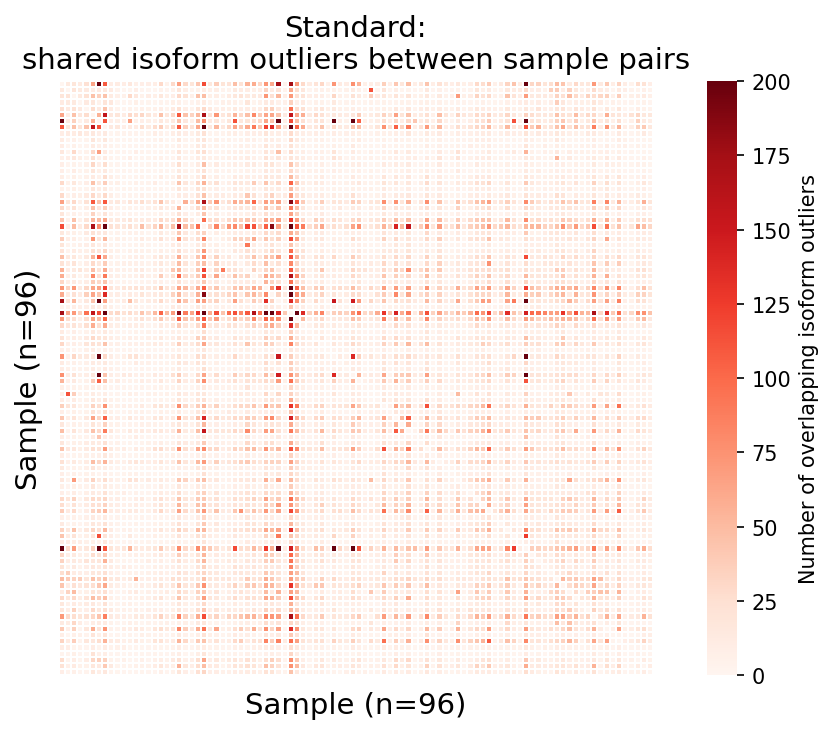

In [258]:
standard_overlap = pair_matrix_to_sample_overlap_heatmap(
    "applied_depletion_gregor_n100/rnu42/standard_pair_by_transcript_signed_score.tsv",
    title="Standard:\nshared isoform outliers between sample pairs",
    cmap="Reds",
    vmin=0,
    vmax=200,
    figsize=(7.5, 5),
    save_path="applied_depletion_gregor_n100/rnu42/standard_pair_overlap_heatmap.png"
)

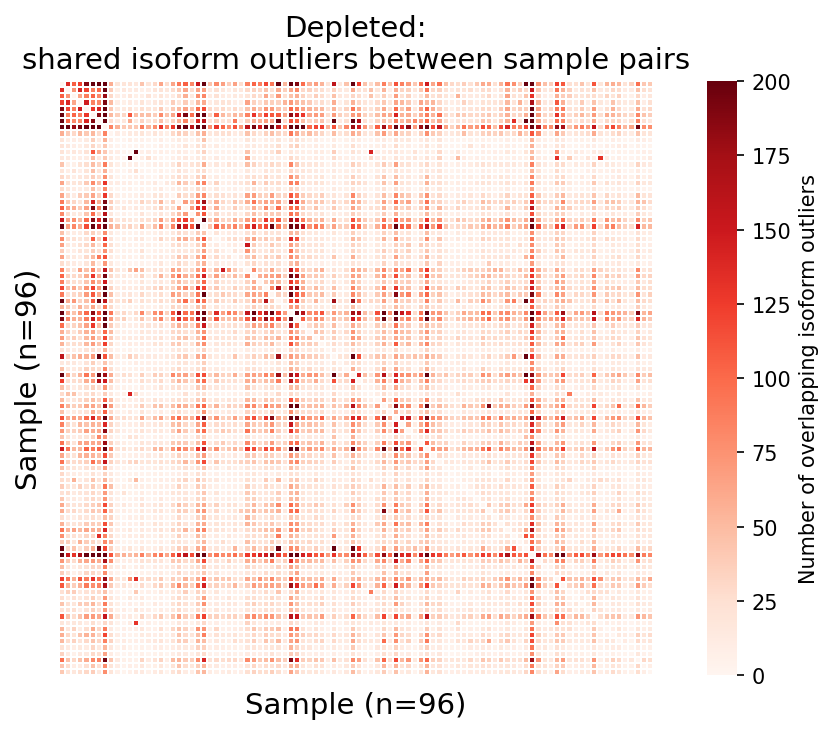

In [259]:
standard_overlap = pair_matrix_to_sample_overlap_heatmap(
    "applied_depletion_gregor_n100/rnu42/depleted_pair_by_transcript_signed_score.tsv",
    title="Depleted:\nshared isoform outliers between sample pairs",
    cmap="Reds",
    vmin=0,
    vmax=200,
    figsize=(7.5, 5),
    save_path="applied_depletion_gregor_n100/rnu42/depleted_pair_overlap_heatmap.png"
)

In [280]:
def load_pair_outlier_counts(pair_matrix_tsv: str, condition_label: str) -> pd.DataFrame:
    """
    Load a pair x transcript signed-score matrix and return one row per pair
    with the total number of nonzero outliers.
    """
    mat = pd.read_csv(pair_matrix_tsv, sep="\t", index_col=0)

    out = pd.DataFrame({
        "pair": mat.index,
        "n_outliers": (mat != 0).sum(axis=1).values,
        "condition": condition_label
    })
    return out


def assign_quantile_bins_within_condition(
    df: pd.DataFrame,
    value_col: str = "n_outliers",
    condition_col: str = "condition",
    n_bins: int = 5
) -> pd.DataFrame:
    """
    Assign quantile bins separately within each condition.

    Uses rank() before qcut() so ties do not collapse bins.
    """
    bin_labels = [
        "0-20%",
        "20-40%",
        "40-60%",
        "60-80%",
        "80-100%"
    ][:n_bins]

    out = df.copy()

    def _bin_group(g):
        r = g[value_col].rank(method="first")
        g = g.copy()
        g["bin"] = pd.qcut(r, q=n_bins, labels=bin_labels)
        return g

    out = (
        out.groupby(condition_col, group_keys=False)
           .apply(_bin_group)
           .reset_index(drop=True)
    )

    out["bin"] = pd.Categorical(out["bin"], categories=bin_labels, ordered=True)
    return out


def plot_binned_pair_outlier_burden(
    standard_tsv: str = "standard_pair_by_transcript_signed_score.tsv",
    depleted_tsv: str = "depleted_pair_by_transcript_signed_score.tsv",
):
    # ----------------------------
    # Load
    # ----------------------------
    df_std = load_pair_outlier_counts(standard_tsv, "Standard")
    df_dep = load_pair_outlier_counts(depleted_tsv, "Depleted")
    df = pd.concat([df_std, df_dep], ignore_index=True)

    # ----------------------------
    # Bin within each condition
    # ----------------------------
    df = assign_quantile_bins_within_condition(df, value_col="n_outliers", condition_col="condition", n_bins=5)

    palette = {
        "Standard": "lightgrey",
        "Depleted": "firebrick",
    }

    # ----------------------------
    # Plot
    # ----------------------------
    fig, axes = plt.subplots(1, 1, figsize=(7, 5), dpi=150)

    # Boxplot
    sns.boxplot(
        data=df,
        x="bin",
        y="n_outliers",
        hue="condition",
        order=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
        hue_order=["Standard", "Depleted"],
        palette=palette,
        showfliers=False,
        width=0.7,
        ax=axes
    )
    axes.set_title("Number of Shared Outliers (Binned)", fontsize=14)
    axes.set_xlabel("Pair-outlier quantile bin", fontsize=14)
    axes.set_ylabel("Number of shared outliers", fontsize=14)
    axes.spines["top"].set_visible(False)
    axes.spines["right"].set_visible(False)
    axes.set_ylim(0, 200)
    axes.grid(axis="y", alpha=0.2)
    axes.legend(title="", fontsize=10)

    plt.tight_layout()
    plt.savefig("applied_depletion_gregor_n100/rnu42/pair_outlier_burden_by_bin.png", dpi=300)
    plt.show()

    return df




/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_17597/2987323172.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_bin_group)


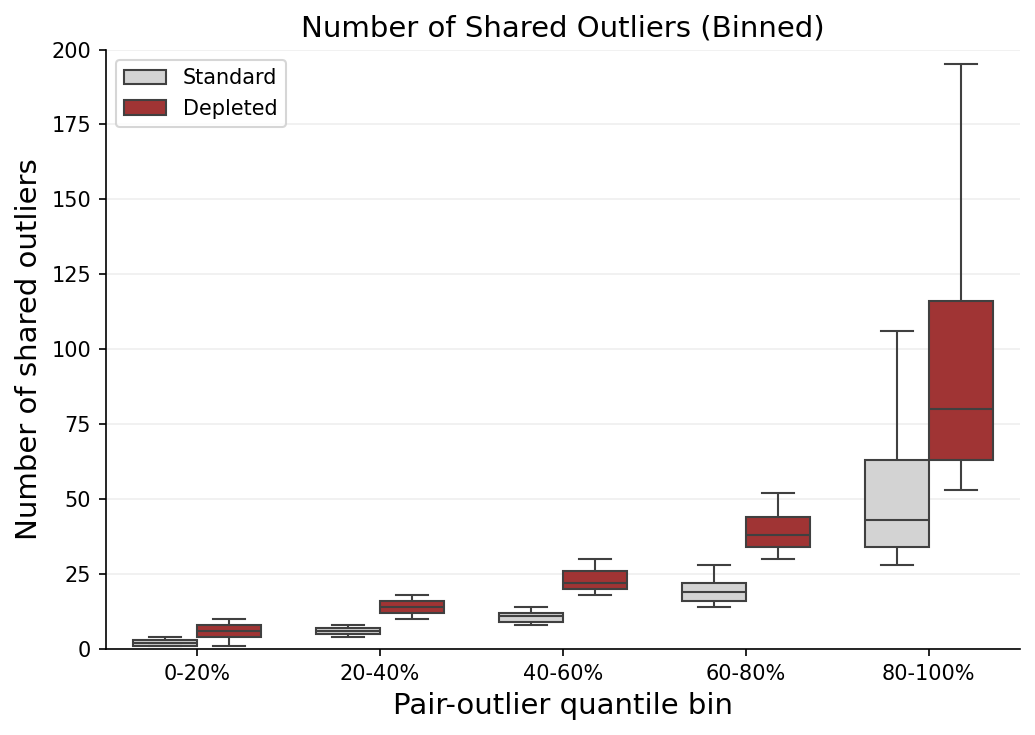

In [281]:
# Run
pair_burden_df = plot_binned_pair_outlier_burden(
    standard_tsv="applied_depletion_gregor_n100/rnu42/standard_pair_by_transcript_signed_score.tsv",
    depleted_tsv="applied_depletion_gregor_n100/rnu42/depleted_pair_by_transcript_signed_score.tsv",
)

In [260]:
#now lets specifically focus on the two RNU4-2 samples
control = pd.read_csv("applied_depletion_gregor_n100/rnu42/pair_results_standard_long.tsv", delimiter="\t")
control = control[(control['sample1']=='5-4-WM') & (control['sample2']=='5-7-WM')]
control_transcripts = set(control['transcript_id'].unique().tolist())

depleted = pd.read_csv("applied_depletion_gregor_n100/rnu42/pair_results_depleted_long.tsv", delimiter="\t")
depleted = depleted[(depleted['sample1']=='5-4-D') & (depleted['sample2']=='5-7-D')]
depleted_transcripts = set(depleted['transcript_id'].unique().tolist())


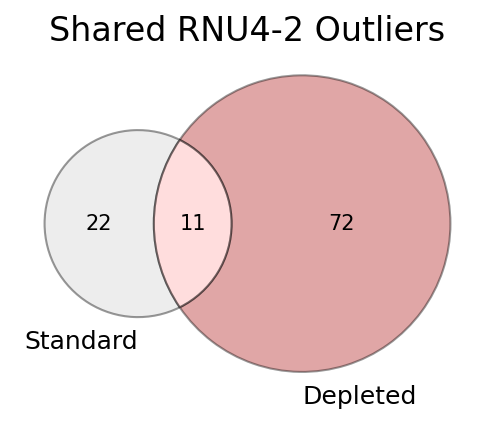

In [266]:
#plot a venndiagram of control transccripts versus depleted transcripts
#with depleted being fire brick and control being grey 
from matplotlib_venn import venn2

plt.figure(figsize=(4, 4), dpi=150)
venn2([control_transcripts, depleted_transcripts], 
      set_colors=('lightgrey', 'firebrick'),
      set_labels=('Standard', 'Depleted'), ax=plt.gca())
#add line edge around
for patch in plt.gca().patches:
    patch.set_edgecolor('black')
    patch.set_linewidth(1)

#add title
plt.title("Shared RNU4-2 Outliers", y=0.98, fontsize=16)
plt.gca().patch.set_facecolor('lightgrey')
plt.gca().patch.set_alpha(0.5)
plt.savefig("applied_depletion_gregor_n100/rnu42/shared_rnu42_outliers.png", dpi=300)
plt.show()


In [220]:
#now get the genes for each of the associated outliers
meta_gene = pd.DataFrame(meta)
meta_gene['transcript_stable_id'] = meta_gene.index
meta_gene = meta_gene[['transcript_stable_id', 'Gene name']]

depleted['stable_transcript_id'] = depleted['transcript_id'].str.split('.').str[0]
depleted_sub = depleted.merge(meta_gene, left_on='stable_transcript_id', right_on='transcript_stable_id', how='left')
depleted_sub = depleted_sub.sort_values('q_raw_dfpost', ascending=True)

control['stable_transcript_id'] = control['transcript_id'].str.split('.').str[0]
control_sub = control.merge(meta_gene, left_on='stable_transcript_id', right_on='transcript_stable_id', how='left')
control_sub = control_sub.sort_values('q_raw_dfpost', ascending=True)


In [ ]:
#import into ENRICHR for GSEA 
genes = depleted_sub[depleted_sub['Gene name'].notna()]['Gene name'].unique().tolist()
control_genes = control_sub[control_sub['Gene name'].notna()]['Gene name'].unique().tolist()
genes = [gene for gene in genes if gene not in control_genes]

#write genes to tab seperated text file
with open("applied_depletion_gregor_n100/rnu42/depleted_genes.txt", "w") as f:
    f.write("\n".join(genes))

In [267]:
#read in enrichr table (top 5 according to p-value)
enrich = pd.read_csv("applied_depletion_gregor_n100/rnu42/GO_Molecular_Function_2025_table.txt", sep="\t")
enrich['-log10(p-value)'] = -np.log10(enrich['P-value'])
enrich = enrich[enrich['P-value'] < 0.05]
enrich = enrich.head(5)
enrich['Term'] = enrich['Term'].str.replace(r"\s*\(.*\)", "", regex=True)
enrich

,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,-log10(p-value)
0,Unmethylated CpG Binding,2/8,0.000221,0.017017,0,0,120.830303,1017.071877,KMT2A;KMT2B,3.655612
1,Histone H3K4 Methyltransferase Activity,2/13,0.000610,0.023486,0,0,65.890909,487.725016,KMT2A;KMT2B,3.214651
2,Acetyltransferase Activity,2/25,0.002295,0.058914,0,0,31.494071,191.385626,SMARCE1;PAFAH2,2.639155
3,Histone H3 Methyltransferase Activity,2/37,0.004985,0.095966,0,0,20.683636,109.649486,KMT2A;KMT2B,2.302311
4,Protein-Lysine N-methyltransferase Activity,2/54,0.010385,0.145278,0,0,13.909790,63.531045,KMT2A;KMT2B,1.983580


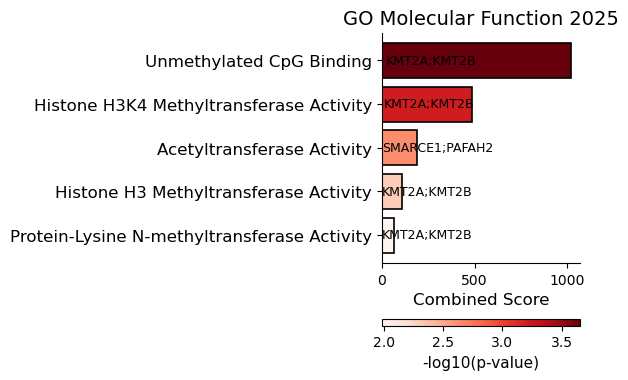

In [279]:
import matplotlib as mpl
# Make a copy so the original dataframe stays unchanged
df = enrich.copy()

# Optional: sort so the strongest term is at the top
df = df.sort_values("Combined Score", ascending=True)

# Set up color mapping from -log10(p-value)
norm = mpl.colors.Normalize(
    vmin=df["-log10(p-value)"].min(),
    vmax=df["-log10(p-value)"].max()
)
cmap = plt.cm.Reds
colors = cmap(norm(df["-log10(p-value)"].values))

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

# Horizontal bar plot
bars = ax.barh(
    y=df["Term"],
    width=df["Combined Score"],
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# Add genes as text inside bars
for bar, genes, score in zip(bars, df["Genes"], df["Combined Score"]):
    y = bar.get_y() + bar.get_height() / 2
    x = score * 0.02 if score > 0 else 0.5

    ax.text(
        x,
        y,
        genes,
        va="center",
        ha="left",
        fontsize=9,
        color="black"
    )

# Labels and title
ax.set_xlabel("Combined Score", fontsize=12)
ax.set_title("GO Molecular Function 2025", fontsize=14)

# Horizontal colorbar below plot
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    pad=0.18,      # distance below axes
    fraction=0.08, # thickness of colorbar
    aspect=30     # length/thickness ratio
)
cbar.set_label("-log10(p-value)", fontsize=11)

# Improve layout
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Extra room for long term names and bottom colorbar
plt.tight_layout()
plt.savefig(
    "applied_depletion_gregor_n100/rnu42/gsea_barplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Get outlier plots for these top Genes 
-

In [185]:
depleted_sub

,transcript_id,pair_label,sample1,sample2,z1,z2,diff_log2_median,q_raw_dfpost,final_high_flag,final_low_flag,final_any_flag,condition,stable_transcript_id,transcript_stable_id,Gene name
48,ENST00000630983.1,5-4__5-7,5-4-D,5-7-D,2.139722e+01,1.496140e+01,1.923182,2.534769e-38,True,False,True,Depleted,ENST00000630983,ENST00000630983,POLR1D
32,ENST00000674564.1,5-4__5-7,5-4-D,5-7-D,4.869609e+01,3.572152e+01,1.334315,1.809167e-30,True,False,True,Depleted,ENST00000674564,ENST00000674564,KDM6A
17,ENST00000428808.5,5-4__5-7,5-4-D,5-7-D,1.201657e+01,9.596075e+00,1.833796,2.104153e-27,True,False,True,Depleted,ENST00000428808,ENST00000428808,BRD8
40,ENST00000529927.5,5-4__5-7,5-4-D,5-7-D,2.956057e+06,2.117695e+06,2.536876,1.193656e-23,True,False,True,Depleted,ENST00000529927,ENST00000529927,NDUFV1
52,ENST00000528182.5,5-4__5-7,5-4-D,5-7-D,1.027937e+01,8.435699e+00,2.937000,6.360971e-20,True,False,True,Depleted,ENST00000528182,ENST00000528182,SDHD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,ENST00000686920.1,5-4__5-7,5-4-D,5-7-D,1.456586e+01,7.486966e+00,1.482910,3.297867e-02,True,False,True,Depleted,ENST00000686920,ENST00000686920,KMT2B
62,ENST00000566714.1,5-4__5-7,5-4-D,5-7-D,-4.300347e+00,-4.300347e+00,-3.153804,3.649252e-02,False,True,True,Depleted,ENST00000566714,NaN,NaN
50,ENST00000420670.5,5-4__5-7,5-4-D,5-7-D,1.448901e+06,1.130931e+06,1.289916,3.858264e-02,True,False,True,Depleted,ENST00000420670,ENST00000420670,SEMA4D
55,ENST00000449702.1,5-4__5-7,5-4-D,5-7-D,1.250962e+06,9.030383e+05,1.077000,4.182466e-02,True,False,True,Depleted,ENST00000449702,ENST00000449702,RPL31P18


In [94]:
#counts TPM 
counts = pd.read_csv("applied_depletion_gregor_n100/rsem/isoforms_TPM.tsv", sep="\t")
special_samples = ['5-4-D','5-7-D']
all_columns = [col for col in counts.columns if '-D' in col]
counts = counts.set_index('transcript_id')
counts = counts[all_columns]
counts

,1-1-D,1-2-D,1-3-D,1-4-D,1-5-D,1-6-D,1-7-D,1-8-D,10-1-D,10-2-D,...,8-7-D,8-8-D,9-1-D,9-2-D,9-3-D,9-4-D,9-5-D,9-6-D,9-7-D,9-8-D
transcript_id,,,,,,,,,,,,,,,,,,,,,
ENST00000373020.9,0.18,0.44,0.33,0.15,0.15,0.35,0.32,0.40,0.37,0.12,...,0.36,0.08,0.35,0.28,0.34,0.11,0.25,0.23,0.21,0.15
ENST00000494424.1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ENST00000496771.5,0.17,0.24,0.14,0.00,0.10,0.00,0.05,0.47,0.13,0.15,...,0.21,0.02,0.07,0.14,0.13,0.04,0.03,0.00,0.00,0.03
ENST00000612152.4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ENST00000373031.5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000409293.6,27.32,23.19,17.05,18.48,16.87,12.71,19.63,22.77,19.82,12.76,...,19.44,11.61,12.57,12.74,18.52,16.79,11.42,18.54,21.26,18.28
ENST00000485191.5,0.75,0.70,0.52,0.36,0.48,0.13,0.26,0.40,0.57,0.39,...,0.65,0.39,0.46,0.52,0.73,0.48,0.65,0.75,0.53,0.50
ENST00000585716.3,0.00,0.00,0.00,0.00,0.13,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.27,0.00,0.40,0.00,0.00


In [195]:
special_samples = ['5-4-D', '5-7-D']
genes_to_plot = ['KDM6A', 'KMT2A', 'KMT2B']

# ----------------------------
# Pick one transcript per gene
# strongest outlier effect = both specials high, so use min(z1, z2)
# ----------------------------
plot_meta = depleted_sub[depleted_sub['Gene name'].isin(genes_to_plot)].copy()

if plot_meta.empty:
    raise ValueError("No rows found in depleted_sub for Gene name == KDM6A or KMT2A")

plot_meta['outlier_score'] = plot_meta[['z1', 'z2']].min(axis=1)

plot_meta = (
    plot_meta
    .sort_values(['Gene name', 'outlier_score'], ascending=[True, False])
    .groupby('Gene name', as_index=False)
    .head(1)
    .copy()
)
# Keep requested order
plot_meta['Gene name'] = pd.Categorical(plot_meta['Gene name'], categories=genes_to_plot, ordered=True)
plot_meta = plot_meta.sort_values('Gene name')

In [196]:
plot_meta

,transcript_id,pair_label,sample1,sample2,z1,z2,diff_log2_median,q_raw_dfpost,final_high_flag,final_low_flag,final_any_flag,condition,stable_transcript_id,transcript_stable_id,Gene name,outlier_score
32,ENST00000674564.1,5-4__5-7,5-4-D,5-7-D,4.869609e+01,3.572152e+01,1.334315,1.809167e-30,True,False,True,Depleted,ENST00000674564,ENST00000674564,KDM6A,3.572152e+01
19,ENST00000531904.7,5-4__5-7,5-4-D,5-7-D,2.922198e+06,1.914565e+06,2.418381,1.639758e-04,True,False,True,Depleted,ENST00000531904,ENST00000531904,KMT2A,1.914565e+06
66,ENST00000686920.1,5-4__5-7,5-4-D,5-7-D,1.456586e+01,7.486966e+00,1.482910,3.297867e-02,True,False,True,Depleted,ENST00000686920,ENST00000686920,KMT2B,7.486966e+00


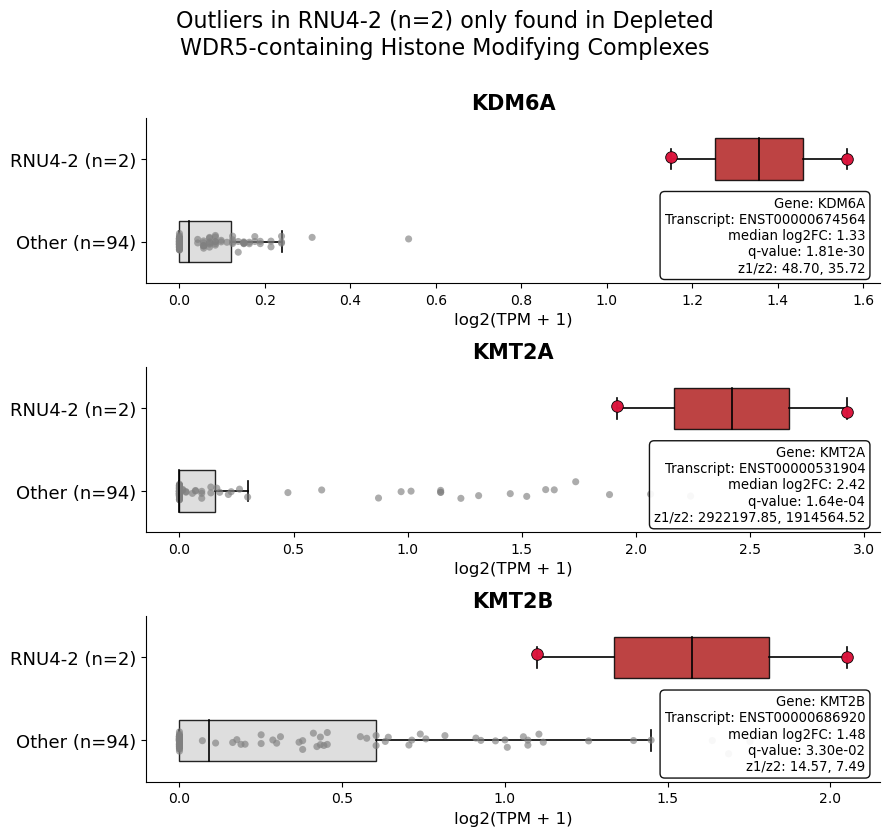

In [199]:
# ----------------------------
# Build long dataframe for plotting
# ----------------------------
records = []

for _, row in plot_meta.iterrows():
    tx = row['transcript_id']
    gene = row['Gene name']
    transcript_name = row['stable_transcript_id'] if pd.notna(row['stable_transcript_id']) else tx

    if tx not in counts.index:
        print(f"Skipping {tx} because it is not present in counts index")
        continue

    vals = counts.loc[tx]

    tmp = pd.DataFrame({
        'sample': vals.index,
        'TPM': vals.values
    })

    tmp['group'] = np.where(tmp['sample'].isin(special_samples), 'RNU4-2', 'Other')
    tmp['Gene name'] = gene
    tmp['Transcript'] = transcript_name
    tmp['transcript_id'] = tx

    # carry annotation fields from merged
    tmp['diff_log2_median'] = row['diff_log2_median']
    tmp['q-value'] = row['q_raw_dfpost']
    tmp['z1'] = row['z1']
    tmp['z2'] = row['z2']

    records.append(tmp)

plot_long = pd.concat(records, ignore_index=True)

# Plot on log scale of TPM
plot_long['plot_value'] = np.log2(plot_long['TPM'] + 1)
xlab = 'log2(TPM + 1)'

# ----------------------------
# Plot: horizontal, stacked vertically
# ----------------------------
unique_genes = plot_meta['Gene name'].tolist()
fig, axes = plt.subplots(len(unique_genes), 1, figsize=(9, 2.8 * len(unique_genes)), sharex=False)

if len(unique_genes) == 1:
    axes = [axes]

rng = np.random.default_rng(7)

for ax, gene in zip(axes, unique_genes):
    sub = plot_long[plot_long['Gene name'] == gene].copy()
    ann = sub.iloc[0]

    other_vals = sub.loc[sub['group'] == 'Other', 'plot_value'].values
    special_vals = sub.loc[sub['group'] == 'RNU4-2', 'plot_value'].values

    # Horizontal boxplots
    bp = ax.boxplot(
        [other_vals, special_vals],
        positions=[0, 1],
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        vert=False
    )

    bp['boxes'][0].set(facecolor='#d9d9d9', edgecolor='black', alpha=0.85)
    bp['boxes'][1].set(facecolor='firebrick', edgecolor='black', alpha=0.85)

    for item in bp['whiskers'] + bp['caps'] + bp['medians']:
        item.set(color='black', linewidth=1.2)

    # Jittered points
    y_other = rng.normal(0, 0.05, size=len(other_vals))
    y_special = rng.normal(1, 0.03, size=len(special_vals))

    ax.scatter(
        other_vals, y_other,
        s=26, alpha=0.65, color='gray', edgecolor='none', zorder=2
    )

    ax.scatter(
        special_vals, y_special,
        s=70, alpha=0.98, color='crimson', edgecolor='black', linewidth=0.6, zorder=3
    )

    # Label the special samples next to the points
    special_rows = sub[sub['group'] == 'RNU4-2'].copy()
    special_rows = special_rows.sort_values('sample')

    # Annotation block
    annotation = (
        f"Gene: {ann['Gene name']}\n"
        f"Transcript: {ann['Transcript']}\n"
        f"median log2FC: {ann['diff_log2_median']:.2f}\n"
        f"q-value: {ann['q-value']:.2e}\n"
        f"z1/z2: {ann['z1']:.2f}, {ann['z2']:.2f}"
    )

    ax.text(
        0.98, 0.05, annotation,
        transform=ax.transAxes,
        ha='right', va='bottom',
        fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='black', alpha=0.92)
    )

    ax.set_title(str(gene), fontsize=15, fontweight='bold')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Other (n=94)', 'RNU4-2 (n=2)'], fontsize=13)
    ax.set_xlabel(xlab, fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=10)

fig.suptitle('Outliers in RNU4-2 (n=2) only found in Depleted\nWDR5-containing Histone Modifying Complexes', fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig("applied_depletion_gregor_n100/rnu42/Outlier_jitter_KDM6A_boxplots.png", dpi=300)
plt.show()

In [200]:
special_samples = ['5-4-D', '5-7-D']
genes_to_plot = ['SMARCE1', 'PAFAH2']

# ----------------------------
# Pick one transcript per gene
# strongest outlier effect = both specials high, so use min(z1, z2)
# ----------------------------
plot_meta = depleted_sub[depleted_sub['Gene name'].isin(genes_to_plot)].copy()

if plot_meta.empty:
    raise ValueError("No rows found in depleted_sub for Gene name == KDM6A or KMT2A")

plot_meta['outlier_score'] = plot_meta[['z1', 'z2']].min(axis=1)

plot_meta = (
    plot_meta
    .sort_values(['Gene name', 'outlier_score'], ascending=[True, False])
    .groupby('Gene name', as_index=False)
    .head(1)
    .copy()
)
# Keep requested order
plot_meta['Gene name'] = pd.Categorical(plot_meta['Gene name'], categories=genes_to_plot, ordered=True)
plot_meta = plot_meta.sort_values('Gene name')
plot_meta

,transcript_id,pair_label,sample1,sample2,z1,z2,diff_log2_median,q_raw_dfpost,final_high_flag,final_low_flag,final_any_flag,condition,stable_transcript_id,transcript_stable_id,Gene name,outlier_score
1,ENST00000646482.1,5-4__5-7,5-4-D,5-7-D,2.035624e+06,1.459432e+06,1.747528,0.000213,True,False,True,Depleted,ENST00000646482,ENST00000646482,SMARCE1,1.459432e+06
35,ENST00000464540.1,5-4__5-7,5-4-D,5-7-D,1.604071e+06,8.797058e+05,1.241889,0.000622,True,False,True,Depleted,ENST00000464540,ENST00000464540,PAFAH2,8.797058e+05


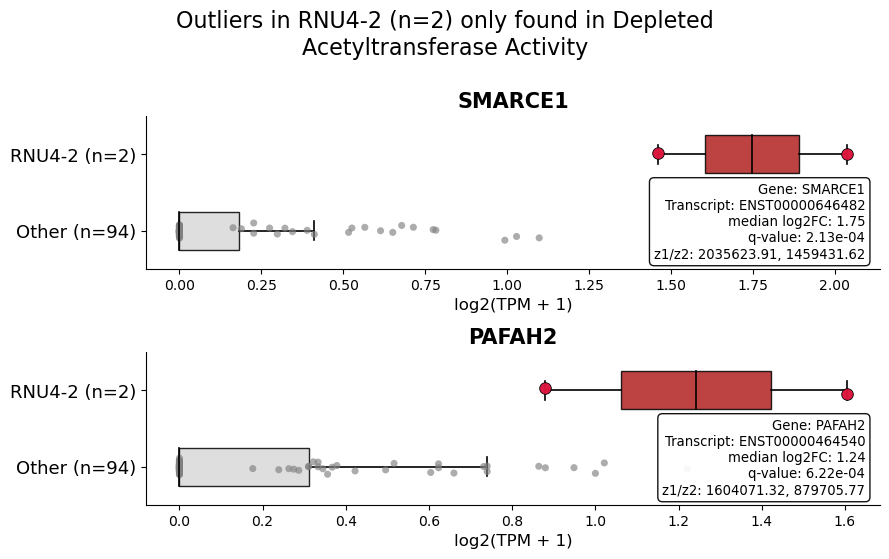

In [201]:
# ----------------------------
# Build long dataframe for plotting
# ----------------------------
records = []

for _, row in plot_meta.iterrows():
    tx = row['transcript_id']
    gene = row['Gene name']
    transcript_name = row['stable_transcript_id'] if pd.notna(row['stable_transcript_id']) else tx

    if tx not in counts.index:
        print(f"Skipping {tx} because it is not present in counts index")
        continue

    vals = counts.loc[tx]

    tmp = pd.DataFrame({
        'sample': vals.index,
        'TPM': vals.values
    })

    tmp['group'] = np.where(tmp['sample'].isin(special_samples), 'RNU4-2', 'Other')
    tmp['Gene name'] = gene
    tmp['Transcript'] = transcript_name
    tmp['transcript_id'] = tx

    # carry annotation fields from merged
    tmp['diff_log2_median'] = row['diff_log2_median']
    tmp['q-value'] = row['q_raw_dfpost']
    tmp['z1'] = row['z1']
    tmp['z2'] = row['z2']

    records.append(tmp)

plot_long = pd.concat(records, ignore_index=True)

# Plot on log scale of TPM
plot_long['plot_value'] = np.log2(plot_long['TPM'] + 1)
xlab = 'log2(TPM + 1)'

# ----------------------------
# Plot: horizontal, stacked vertically
# ----------------------------
unique_genes = plot_meta['Gene name'].tolist()
fig, axes = plt.subplots(len(unique_genes), 1, figsize=(9, 2.8 * len(unique_genes)), sharex=False)

if len(unique_genes) == 1:
    axes = [axes]

rng = np.random.default_rng(7)

for ax, gene in zip(axes, unique_genes):
    sub = plot_long[plot_long['Gene name'] == gene].copy()
    ann = sub.iloc[0]

    other_vals = sub.loc[sub['group'] == 'Other', 'plot_value'].values
    special_vals = sub.loc[sub['group'] == 'RNU4-2', 'plot_value'].values

    # Horizontal boxplots
    bp = ax.boxplot(
        [other_vals, special_vals],
        positions=[0, 1],
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        vert=False
    )

    bp['boxes'][0].set(facecolor='#d9d9d9', edgecolor='black', alpha=0.85)
    bp['boxes'][1].set(facecolor='firebrick', edgecolor='black', alpha=0.85)

    for item in bp['whiskers'] + bp['caps'] + bp['medians']:
        item.set(color='black', linewidth=1.2)

    # Jittered points
    y_other = rng.normal(0, 0.05, size=len(other_vals))
    y_special = rng.normal(1, 0.03, size=len(special_vals))

    ax.scatter(
        other_vals, y_other,
        s=26, alpha=0.65, color='gray', edgecolor='none', zorder=2
    )

    ax.scatter(
        special_vals, y_special,
        s=70, alpha=0.98, color='crimson', edgecolor='black', linewidth=0.6, zorder=3
    )

    # Label the special samples next to the points
    special_rows = sub[sub['group'] == 'RNU4-2'].copy()
    special_rows = special_rows.sort_values('sample')

    # Annotation block
    annotation = (
        f"Gene: {ann['Gene name']}\n"
        f"Transcript: {ann['Transcript']}\n"
        f"median log2FC: {ann['diff_log2_median']:.2f}\n"
        f"q-value: {ann['q-value']:.2e}\n"
        f"z1/z2: {ann['z1']:.2f}, {ann['z2']:.2f}"
    )

    ax.text(
        0.98, 0.05, annotation,
        transform=ax.transAxes,
        ha='right', va='bottom',
        fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='black', alpha=0.92)
    )

    ax.set_title(str(gene), fontsize=15, fontweight='bold')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Other (n=94)', 'RNU4-2 (n=2)'], fontsize=13)
    ax.set_xlabel(xlab, fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=10)

fig.suptitle('Outliers in RNU4-2 (n=2) only found in Depleted\nAcetyltransferase Activity', fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig("applied_depletion_gregor_n100/rnu42/Outlier_jitter_SMARCE1_boxplots.png", dpi=300)
plt.show()

In [115]:
#SMARCE1 canonical and outlier 
#outlier = ENST00000646482
#canon = ENST00000348513

#KDM6A
#outlier = ENST00000674564
#canon = ENST00000382899

#used for viewing
#https://www.ncbi.nlm.nih.gov/Structure/icn3d/

#used for alignment - foldmason 
#used for structure - alphafold

Now look at the differences between the canonical versus isoform and the regions missing 
-

In [129]:
from matplotlib.patches import Rectangle
import matplotlib as mpl

In [ ]:
def process_interproscan(file):
    # going to remove repetitive and unnecessary databases 
    motifs = pd.read_csv(file, sep='\t', header=None)
    motifs.columns = ['gene', 'run', 'length', 'category', 'database', 'description', 'start', 'end', 'p-value', 'T', 'date', 'ID', 'full_description', 'interpro_accession', 'reactome_acc']
    motifs = motifs[['gene', 'length', 'category', 'database', 'description', 'start', 'end', 'p-value', 'full_description']]
    motifs = motifs[motifs['category'] != 'Phobius']
    motifs = motifs[motifs['category'] != 'Gene3D']
    motifs = motifs[motifs['category'] != 'FunFam']
    motifs = motifs[motifs['category'] != 'PANTHER']
    return motifs

In [182]:
def read_two_seq_aligned_fasta(fasta_file):
    records = []
    header = None
    seq_chunks = []

    with open(fasta_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(seq_chunks)))
                header = line[1:]
                seq_chunks = []
            else:
                seq_chunks.append(line)
        if header is not None:
            records.append((header, "".join(seq_chunks)))

    if len(records) != 2:
        raise ValueError(f"Expected exactly 2 sequences in {fasta_file}, found {len(records)}")

    return records


def contiguous_segments(sorted_positions):
    if len(sorted_positions) == 0:
        return []

    segments = []
    seg_start = sorted_positions[0]
    prev = sorted_positions[0]

    for x in sorted_positions[1:]:
        if x == prev + 1:
            prev = x
        else:
            segments.append((seg_start, prev))
            seg_start = x
            prev = x
    segments.append((seg_start, prev))
    return segments


def build_alignment_maps(canonical_aligned, outlier_aligned):
    if len(canonical_aligned) != len(outlier_aligned):
        raise ValueError("Aligned sequences must be the same length")

    canonical_pos = 0
    outlier_present_positions = []
    mismatch_positions = []
    absent_positions = []

    for c_aa, o_aa in zip(canonical_aligned, outlier_aligned):
        if c_aa != "-":
            canonical_pos += 1

            if o_aa != "-":
                outlier_present_positions.append(canonical_pos)
                if c_aa != o_aa:
                    mismatch_positions.append(canonical_pos)
            else:
                absent_positions.append(canonical_pos)

    altered_positions = sorted(set(mismatch_positions) | set(absent_positions))

    return {
        "canonical_length": canonical_pos,
        "outlier_present_positions": sorted(outlier_present_positions),
        "mismatch_positions": sorted(mismatch_positions),
        "absent_positions": sorted(absent_positions),
        "altered_positions": altered_positions,
    }


def assign_domain_lanes(df):
    """
    Assign each domain to the first non-overlapping lane.
    """
    lane_ends = []
    lane_ids = []

    for _, row in df.iterrows():
        start = int(row["start"])
        end = int(row["end"])

        placed = False
        for lane_idx in range(len(lane_ends)):
            if start > lane_ends[lane_idx]:
                lane_ids.append(lane_idx)
                lane_ends[lane_idx] = end
                placed = True
                break

        if not placed:
            lane_ids.append(len(lane_ends))
            lane_ends.append(end)

    return lane_ids


def plot_isoform_domain_difference(
    motifs,
    fasta_file,
    canonical_header_contains="canonical",
    outlier_header_contains="outlier",
    gene=None,
    figsize=(20, 5),
    protein_height=0.22,
    domain_height=0.22,
    dpi=300,
    fontsize_labels=11,
    fontsize_legend=11,
    canonical_color="#BDBDBD",
    missing_color="#D32F2F",
    mismatch_color="#05A045",
    outlier_color="#BDBDBD",
    linecolor="black",
    linewidth=0.8,
    save=None
):
    # ----------------------------
    # Parse FASTA
    # ----------------------------
    records = read_two_seq_aligned_fasta(fasta_file)
    seq_dict = {h: s for h, s in records}

    canonical_header = None
    outlier_header = None

    for h in seq_dict:
        if canonical_header_contains.lower() in h.lower():
            canonical_header = h
        if outlier_header_contains.lower() in h.lower():
            outlier_header = h

    if canonical_header is None or outlier_header is None:
        headers = list(seq_dict.keys())
        raise ValueError(
            f"Could not identify canonical/outlier headers.\n"
            f"Found headers: {headers}\n"
            f"canonical_header_contains='{canonical_header_contains}', "
            f"outlier_header_contains='{outlier_header_contains}'"
        )

    canonical_aligned = seq_dict[canonical_header]
    outlier_aligned = seq_dict[outlier_header]

    maps = build_alignment_maps(canonical_aligned, outlier_aligned)

    canonical_length = maps["canonical_length"]
    outlier_present_positions = maps["outlier_present_positions"]
    mismatch_positions = maps["mismatch_positions"]
    absent_positions = maps["absent_positions"]
    altered_positions = maps["altered_positions"]

    altered_set = set(altered_positions)

    # ----------------------------
    # Prepare motif dataframe
    # ----------------------------
    motifs_plot = motifs.copy()

    if gene is not None and "gene" in motifs_plot.columns:
        motifs_plot = motifs_plot[motifs_plot["gene"] == gene].copy()

    required_cols = {"start", "end", "description"}
    missing = required_cols - set(motifs_plot.columns)
    if missing:
        raise ValueError(f"motifs is missing required columns: {missing}")

    motifs_plot["start"] = motifs_plot["start"].astype(int)
    motifs_plot["end"] = motifs_plot["end"].astype(int)

    def overlaps_altered(row):
        return any(pos in altered_set for pos in range(row["start"], row["end"] + 1))

    motifs_plot = motifs_plot[motifs_plot.apply(overlaps_altered, axis=1)].copy()
    motifs_plot = motifs_plot.sort_values(["start", "end"]).reset_index(drop=True)

    if len(motifs_plot) > 0:
        motifs_plot["lane"] = assign_domain_lanes(motifs_plot)
    else:
        motifs_plot["lane"] = pd.Series(dtype=int)

    if len(motifs_plot) > 0:
        cmap = plt.get_cmap("tab20")

        unique_descriptions = list(pd.unique(motifs_plot["description"]))
        description_to_color = {
            desc: cmap(i % cmap.N)
            for i, desc in enumerate(unique_descriptions)
        }

        motif_colors = motifs_plot["description"].map(description_to_color).tolist()
    else:
        motif_colors = []
        description_to_color = {}

    # ----------------------------
    # Build segments
    # ----------------------------
    outlier_segments = contiguous_segments(outlier_present_positions)
    absent_segments = contiguous_segments(absent_positions)

    # ----------------------------
    # Figure / row positions
    # Reduced whitespace between the 3 main rows
    # ----------------------------
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    y_outlier = 1.2
    y_canonical = 0.6
    y_domains = 0.0
    domain_lane_spacing = 0.25

    # ----------------------------
    # Row 1: Outlier Isoform
    # ----------------------------
    for start, end in outlier_segments:
        ax.add_patch(
            Rectangle(
                (start - 0.5, y_outlier - protein_height / 2),
                end - start + 1,
                protein_height,
                facecolor=outlier_color,
                edgecolor=linecolor,
                linewidth=linewidth
            )
        )

    # ----------------------------
    # Row 2: Canonical Isoform
    # ----------------------------
    ax.add_patch(
        Rectangle(
            (0.5, y_canonical - protein_height / 2),
            canonical_length,
            protein_height,
            facecolor=canonical_color,
            edgecolor=linecolor,
            linewidth=linewidth
        )
    )

    for start, end in absent_segments:
        ax.add_patch(
            Rectangle(
                (start - 0.5, y_canonical - protein_height / 2),
                end - start + 1,
                protein_height,
                facecolor=missing_color,
                edgecolor=missing_color,
                linewidth=0
            )
        )

    for pos in mismatch_positions:
        ax.add_patch(
            Rectangle(
                (pos - 0.5, y_canonical - protein_height / 2),
                1,
                protein_height,
                facecolor=mismatch_color,
                edgecolor=mismatch_color,
                linewidth=0
            )
        )

    # ----------------------------
    # Row 3: Protein Domains
    # staggered lanes, no text on plot
    # ----------------------------
    domain_handles = []

    for i, (_, row) in enumerate(motifs_plot.iterrows()):
        start = row["start"]
        end = row["end"]
        desc = str(row["description"])
        color = motif_colors[i]
        lane = int(row["lane"])

        y_domain_this = y_domains - lane * domain_lane_spacing

        ax.add_patch(
            Rectangle(
                (start - 0.5, y_domain_this - domain_height / 2),
                end - start + 1,
                domain_height,
                facecolor=color,
                edgecolor=linecolor,
                linewidth=linewidth
            )
        )

        domain_handles.append(
            mpl.patches.Patch(
                facecolor=color,
                edgecolor=linecolor,
                label=desc
            )
        )

    # ----------------------------
    # Styling
    # ----------------------------
    n_lanes = motifs_plot["lane"].max() + 1 if len(motifs_plot) > 0 else 1
    lowest_domain_y = y_domains - (n_lanes - 1) * domain_lane_spacing

    ax.set_xlim(0.5, canonical_length + 0.5)
    ax.set_ylim(lowest_domain_y - 0.28, 1.45)

    ax.set_yticks([y_outlier, y_canonical, y_domains])
    ax.set_yticklabels(
        ["Outlier Isoform", "Canonical Isoform", "Altered Protein\nDomains"],
        fontsize=fontsize_labels + 2
    )

    ax.set_xlabel("Canonical Isoform Amino Acid Position", fontsize=fontsize_labels+2)

    title_gene = gene if gene is not None else (
        motifs["gene"].iloc[0] if "gene" in motifs.columns and len(motifs) > 0 else ""
    )
    ax.set_title(
        f"{title_gene}: Canonical vs Outlier Isoform Structural Differences",
        fontsize=fontsize_labels + 4,
        pad=10
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", labelsize=fontsize_labels - 1)

    for y in [y_outlier, y_canonical, y_domains]:
        ax.axhline(y, color="#EEEEEE", linewidth=0.6, zorder=0)

    # De-duplicate domain legend labels if same description appears multiple times
    unique_domain_handles = []
    seen = set()
    for h in domain_handles:
        if h.get_label() not in seen:
            unique_domain_handles.append(h)
            seen.add(h.get_label())

    base_handles = [
        mpl.patches.Patch(facecolor=missing_color, edgecolor=missing_color, label="Missing in outlier"),
        mpl.patches.Patch(facecolor=mismatch_color, edgecolor=mismatch_color, label="Altered amino acid"),
    ]

    handles = base_handles + unique_domain_handles

    ax.legend(
        handles=handles,
        frameon=False,
        loc="lower left",
        bbox_to_anchor=(0.0, 0.0),
        fontsize=fontsize_legend,
        ncol=1
    )

    plt.tight_layout()

    if save is not None:
        plt.savefig(save, bbox_inches="tight", dpi=dpi)

    plt.show()

    return {
        "canonical_length": canonical_length,
        "mismatch_positions": mismatch_positions,
        "absent_positions": absent_positions,
        "altered_positions": altered_positions,
        "motifs_plotted": motifs_plot
    }

In [237]:
motifs = process_interproscan("applied_depletion_gregor_n100/rnu42/KDM6A_interproscan.tsv")
motifs

,gene,length,category,database,description,start,end,p-value,full_description
0,KDM6A,1408,SUPERFAMILY,SSF81901,HCP-like,170,381,9.42E-24,-
2,KDM6A,1408,ProSiteProfiles,PS50005,TPR repeat profile.,130,163,10.5319,Tetratricopeptide repeat
3,KDM6A,1408,MobiDBLite,mobidb-lite,consensus disorder prediction,1050,1086,-,-
4,KDM6A,1408,SMART,SM00028,tpr_5,205,238,9.1,Tetratricopeptide repeat
5,KDM6A,1408,SMART,SM00028,tpr_5,318,351,0.0057,Tetratricopeptide repeat
6,KDM6A,1408,SMART,SM00028,tpr_5,130,163,0.0017,Tetratricopeptide repeat
7,KDM6A,1408,SMART,SM00028,tpr_5,284,317,0.63,Tetratricopeptide repeat
8,KDM6A,1408,SMART,SM00028,tpr_5,352,385,18.0,Tetratricopeptide repeat
9,KDM6A,1408,SMART,SM00028,tpr_5,93,126,12.0,Tetratricopeptide repeat
10,KDM6A,1408,MobiDBLite,mobidb-lite,consensus disorder prediction,430,471,-,-


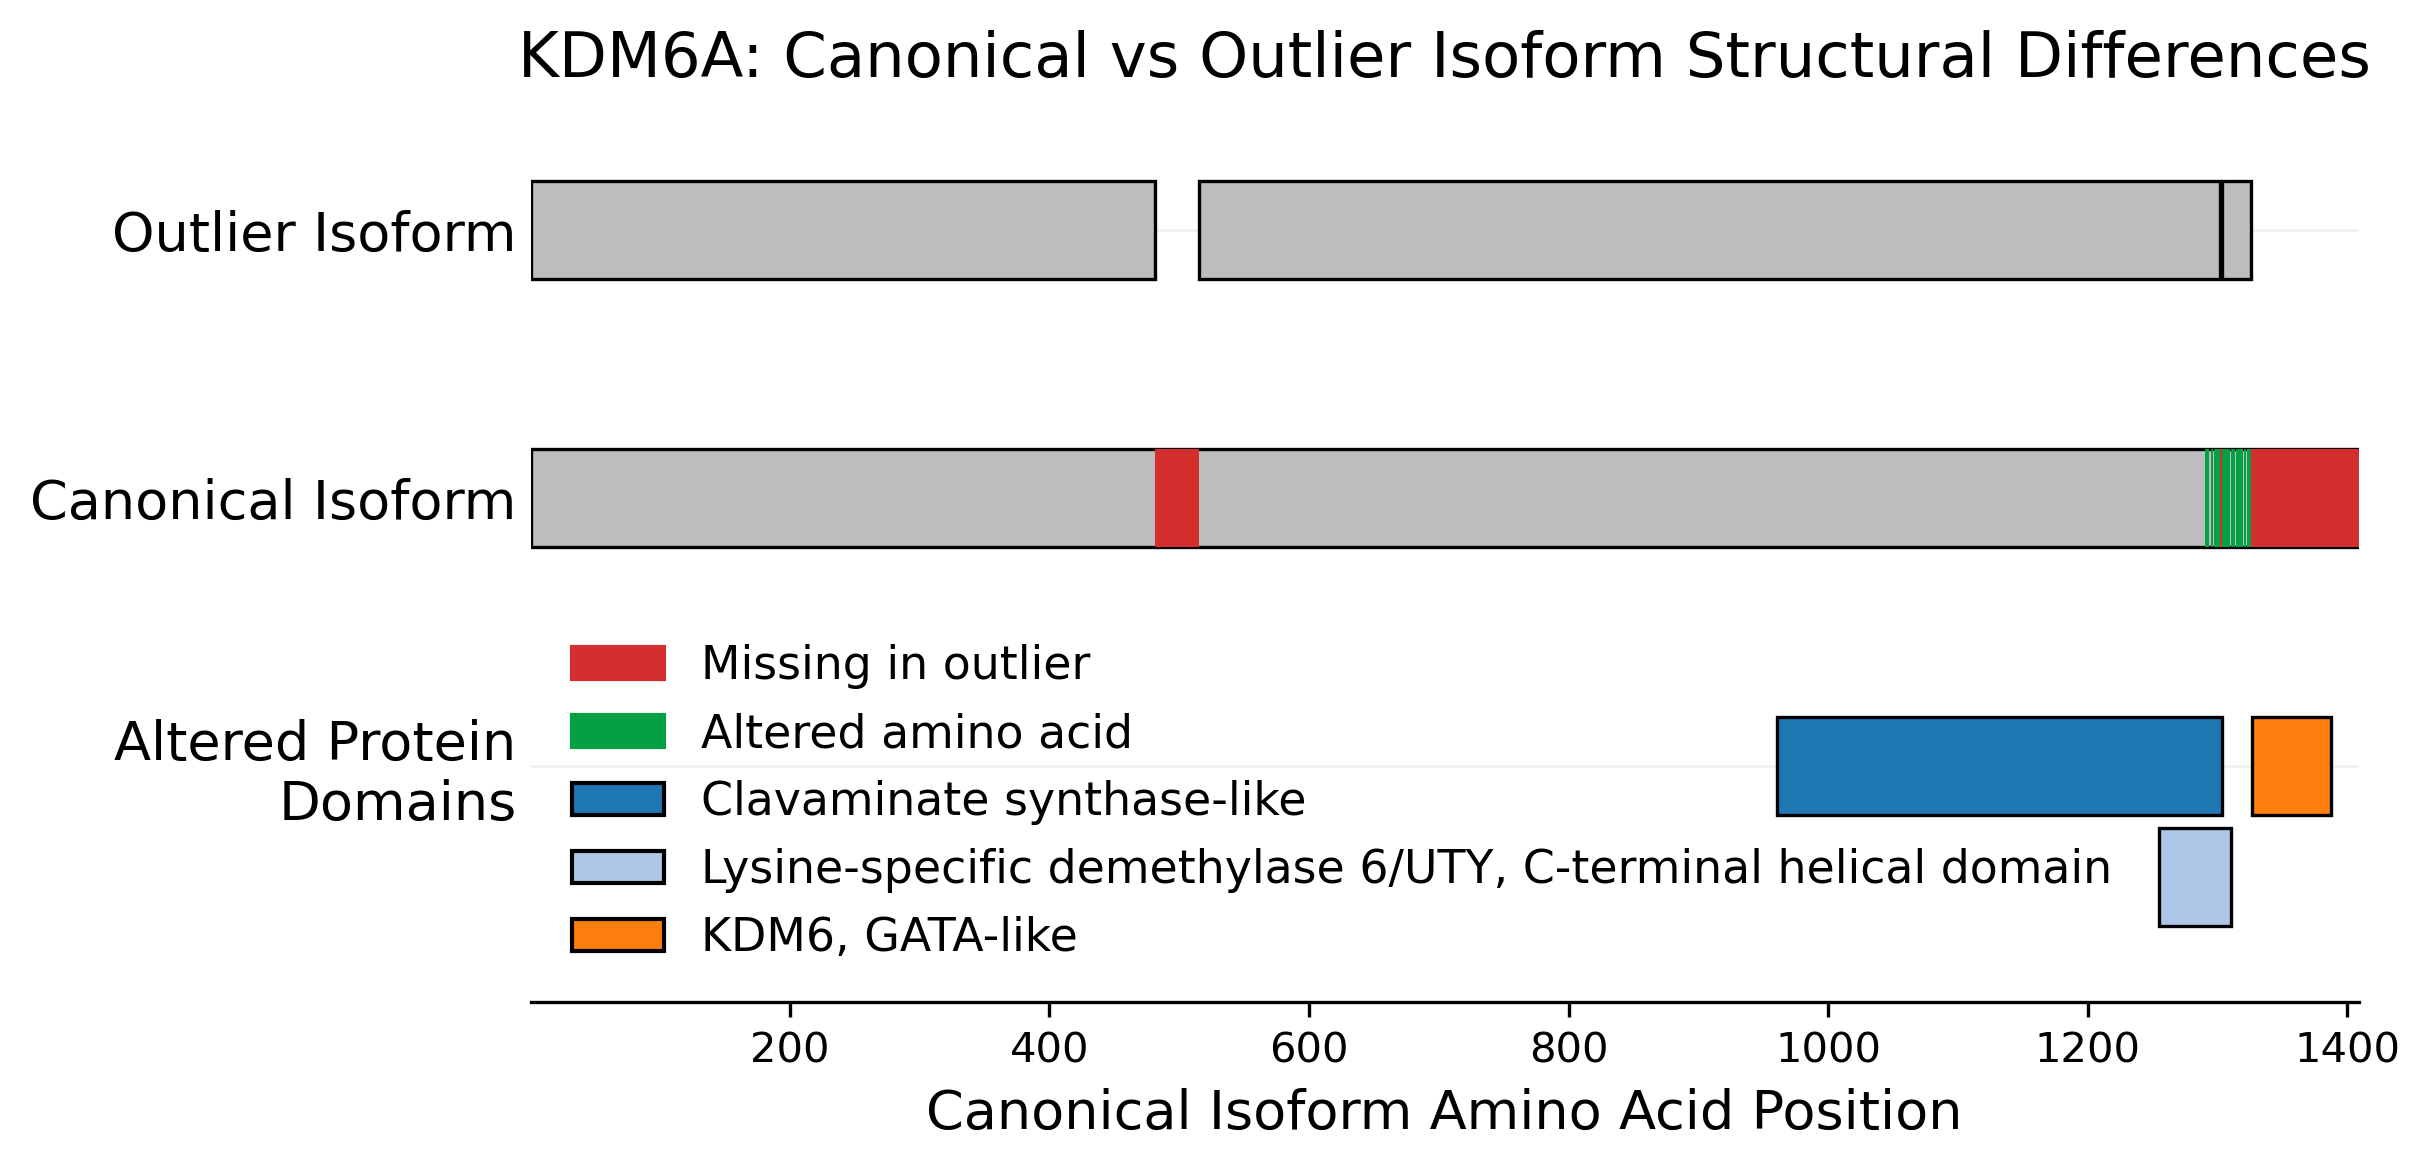

In [240]:
result = plot_isoform_domain_difference(
    motifs=motifs,
    fasta_file="applied_depletion_gregor_n100/rnu42/KDM6A_aligned.fasta",
    canonical_header_contains="canonical",
    outlier_header_contains="outlier",
    gene="KDM6A",
    figsize=(8.2, 4),
    save="applied_depletion_gregor_n100/rnu42/KDM6A_isoform_domain_difference.png"
)

In [241]:
motifs = process_interproscan("applied_depletion_gregor_n100/rnu42/SMARCE1_interproscan.tsv")
motifs

,gene,length,category,database,description,start,end,p-value,full_description
0,SMARCE1,411,MobiDBLite,mobidb-lite,consensus disorder prediction,153,175,-,-
1,SMARCE1,411,MobiDBLite,mobidb-lite,consensus disorder prediction,296,312,-,-
2,SMARCE1,411,ProSiteProfiles,PS50118,HMG boxes A and B DNA-binding domains profile.,66,134,16.048998,High mobility group box domain
3,SMARCE1,411,SUPERFAMILY,SSF47095,HMG-box,57,137,6.68E-24,High mobility group box domain superfamily
4,SMARCE1,411,Coils,Coil,Coil,282,317,-,-
5,SMARCE1,411,Coils,Coil,Coil,224,258,-,-
7,SMARCE1,411,MobiDBLite,mobidb-lite,consensus disorder prediction,42,70,-,-
8,SMARCE1,411,MobiDBLite,mobidb-lite,consensus disorder prediction,296,411,-,-
9,SMARCE1,411,MobiDBLite,mobidb-lite,consensus disorder prediction,383,395,-,-
10,SMARCE1,411,MobiDBLite,mobidb-lite,consensus disorder prediction,1,23,-,-


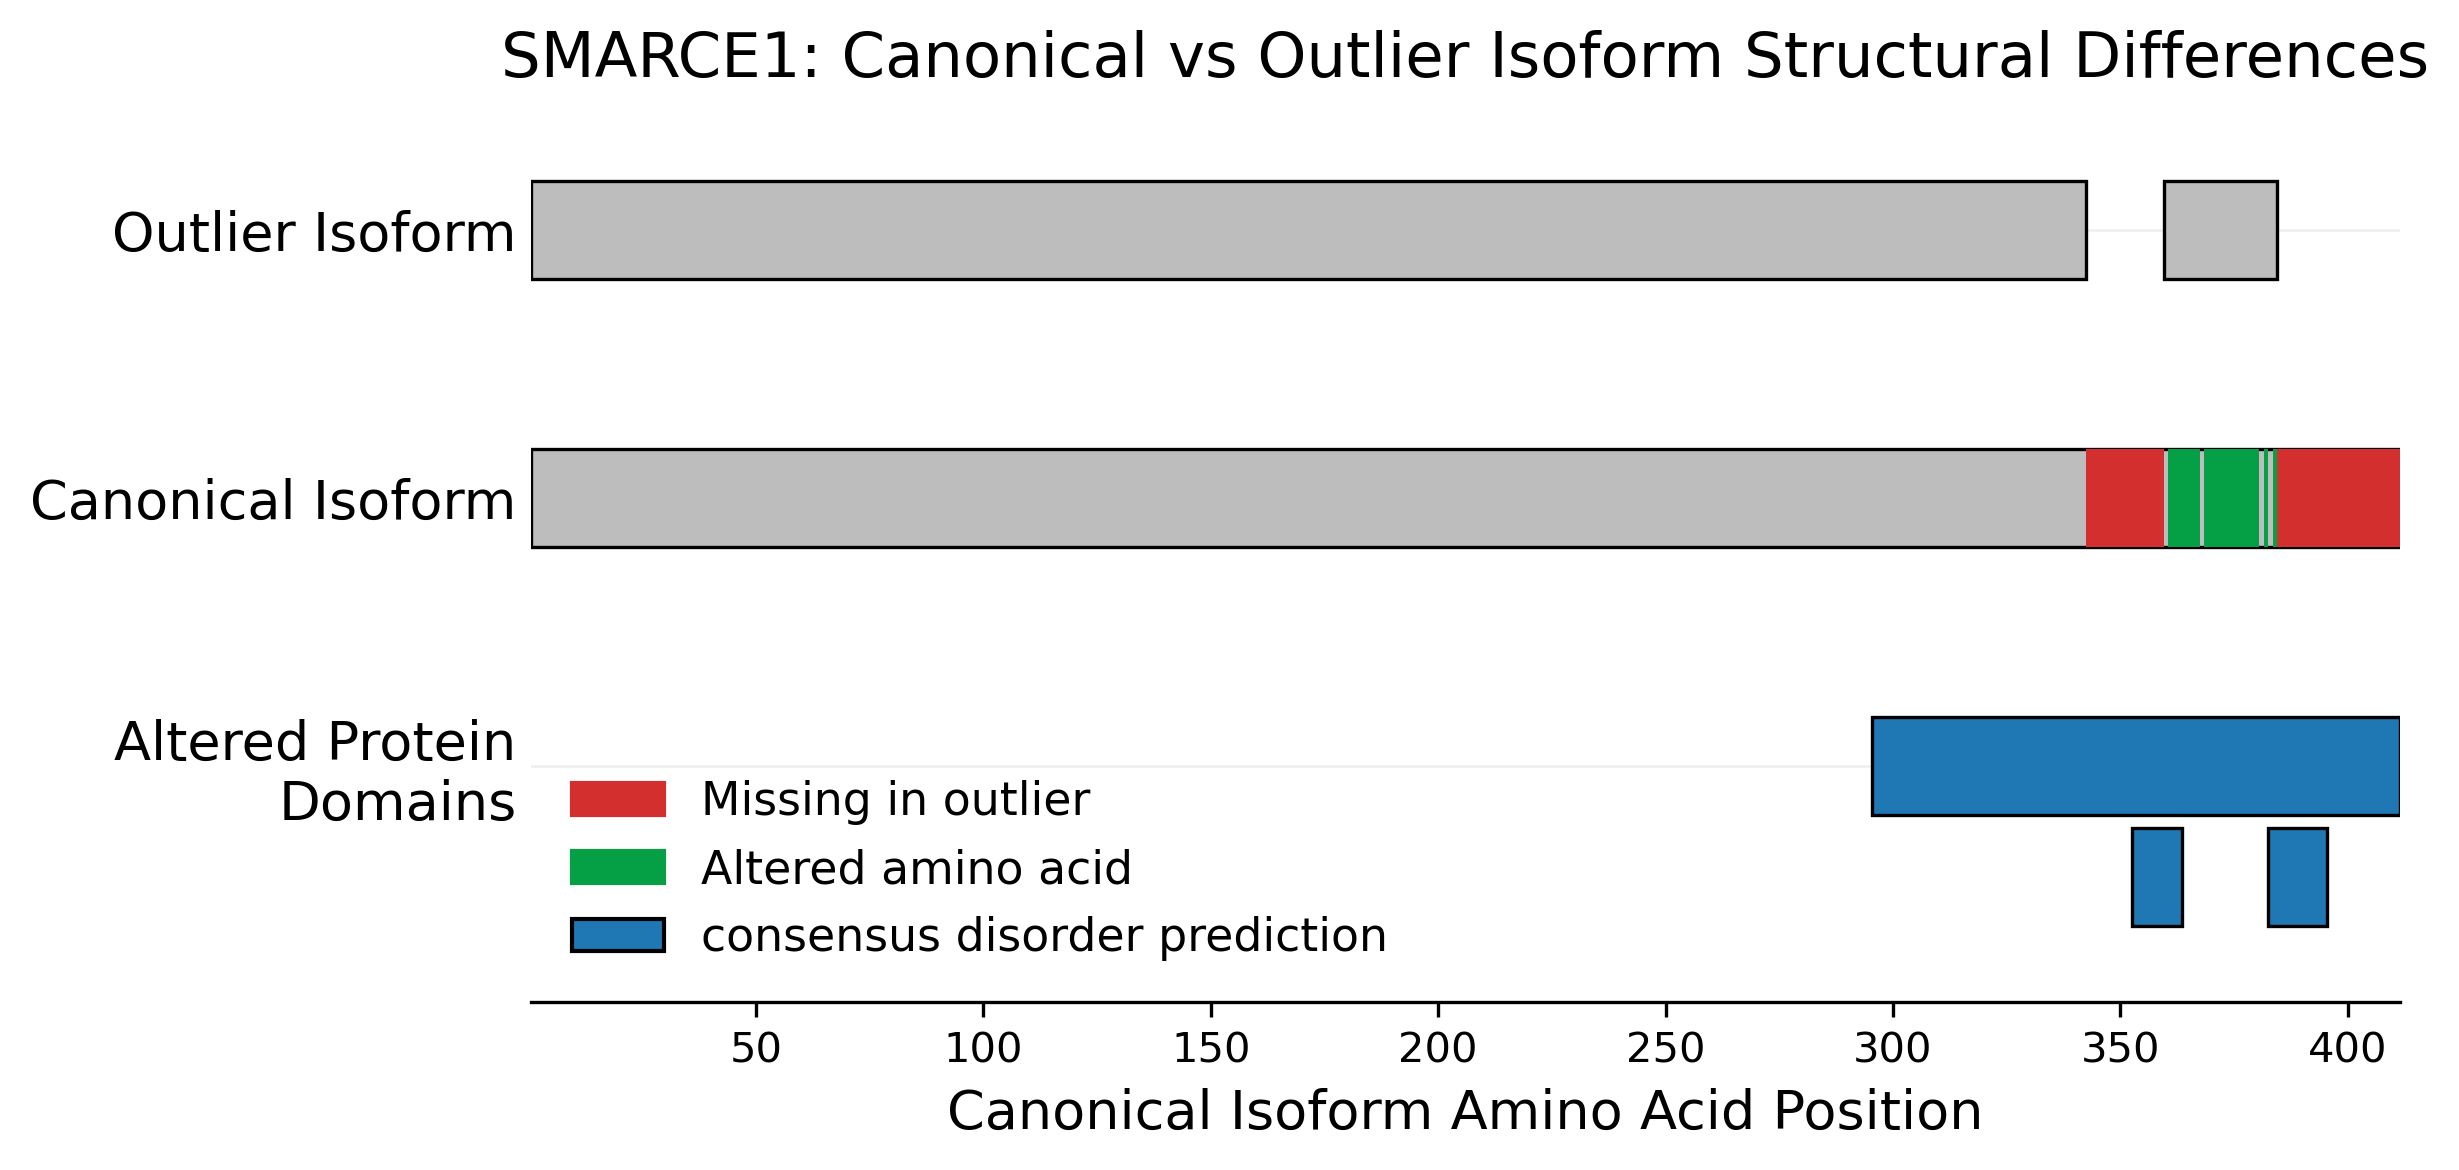

In [242]:
result = plot_isoform_domain_difference(
    motifs=motifs,
    fasta_file="applied_depletion_gregor_n100/rnu42/SMARCE1_aligned.fasta",
    canonical_header_contains="canonical",
    outlier_header_contains="outlier",
    gene="SMARCE1",
    figsize=(8.2, 4),
    save="applied_depletion_gregor_n100/rnu42/SMARCE1_isoform_domain_difference.png"
)